# Explainable Multi-Task Deep Learning for Pathological Myopia
**Quantitative structural phenotyping and severity assessment from colour fundus images**

**Objective.** Benchmark six CNN/Transformer backbones on pathological myopia (PM), improve the five non-benchmark models with controlled experiments, then use the strongest model for a multi-task analysis (PM, severity, optic disc, fovea, atrophy/lesions, tessellation, spatial distribution) with explainability.

*Status: written before the datasets were attached. Cells marked **[FILL AFTER INSPECTION]** depend on the real folder structure. No results are included.*

## 2. Research motivation and task summary
Image-level classification says *whether* PM is present, not *where* or *how much*. This study adds structure-level measurements so severity can be tied to quantities that can be checked against the image.

| Task | Output | Needs |
|---|---|---|
| PM classification | PM / non-PM | image label |
| Severity | 5 maculopathy levels | severity label |
| Optic disc / atrophy / lesion / tessellation | pixel masks | masks |
| Fovea localization | (x, y) | coordinates |
| Quantification | area, density, distances | masks (+ fovea) |

**Rule:** a task is trained only where its annotation exists. Missing annotation is never treated as negative.

## 3. Dataset overview
Roles taken from the dataset inspection.

| Dataset | Used for | Not available |
|---|---|---|
| PALM | PM classification (`Label`), fovea (x, y); disc/atrophy masks only if their folders are set in section 9 | severity |
| MMAC 2023 (tasks 1-2) | 5-level severity; lacquer-crack, CNV and Fuchs-spot masks | PM label (unless a grade rule is set), fovea |
| HRF-Seg+ (replaces HPMI) | optic disc masks | PM label, severity, fovea, other masks |
| MCTN Fundus | images only | no annotation table found; all labels unknown |

MMAC task 3 (spherical equivalent) is attached for inspection but not used by any task here.

## 4. Environment setup
Turn on a GPU and Internet (needed once to download timm pretrained weights).

In [2]:
!nvidia-smi

Tue Oct  6 11:41:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 5. Imports

In [3]:
import os, json, time, random, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from timm.layers import resample_abs_pos_embed
import albumentations as A
from albumentations.pytorch import ToTensorV2

from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import spearmanr
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, f1_score,
                             precision_score, recall_score, confusion_matrix, cohen_kappa_score)

warnings.filterwarnings('ignore')
print('torch', torch.__version__, '| timm', timm.__version__, '| albumentations', A.__version__)

torch 2.11.0+cu128 | timm 1.0.29 | albumentations 2.0.8


### Seed and device
One seed everywhere so the benchmark can be repeated.

In [4]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

set_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
print('device:', DEVICE, '| mixed precision:', USE_AMP)

device: cuda | mixed precision: True


## 6. Kaggle Input discovery and health check
Nothing is assumed about folder names. First list what is attached.

In [5]:
INPUT_DIR = Path('/kaggle/input')
IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

for d in sorted(INPUT_DIR.iterdir()):
    files = [p for p in d.rglob('*') if p.is_file()]
    print(f'{d.name}: {len(files)} files')
    print(pd.Series([p.suffix.lower() for p in files]).value_counts().to_string(), '\n')

datasets: 6769 files
.png     3175
.bmp     2038
.jpg     1534
.csv       11
.xlsx       9
.pth        1
.txt        1 



In [6]:
for d in sorted(INPUT_DIR.iterdir()):
    print(d.name)
    for sub in sorted(p for p in d.rglob('*') if p.is_dir() and len(p.relative_to(d).parts) <= 2):
        n_files = sum(1 for f in sub.iterdir() if f.is_file())
        print('   ', sub.relative_to(d), '|', n_files, 'files')

datasets
    kabhishekk1 | 0 files
    kabhishekk1/retfound-cfp-weights | 1 files
    rithikaa7 | 0 files
    rithikaa7/hrf-seg | 0 files
    rithikaa7/mctn-mpm | 0 files
    rithikaa7/mmac-1 | 0 files
    rithikaa7/mmac-2 | 0 files
    rithikaa7/mmac-3 | 0 files
    rithikaa7/palm-pm | 0 files


Health check: can every image be opened, and what sizes/modes exist per top-level folder?

In [7]:
DATA_ROOT = INPUT_DIR / 'datasets' / 'rithikaa7'
records = []
image_files = [p for p in DATA_ROOT.rglob('*') if p.suffix.lower() in IMG_EXT]
for p in tqdm(image_files):
    folder = p.relative_to(DATA_ROOT).parts[0]
    try:
        with Image.open(p) as im:
            w, h, mode = im.size[0], im.size[1], im.mode
            im.verify()
        records.append((str(p), folder, w, h, mode, True))
    except Exception:
        records.append((str(p), folder, None, None, None, False))

inventory = pd.DataFrame(records, columns=['path', 'folder', 'width', 'height', 'mode', 'readable'])
inventory.groupby('folder').agg(n_images=('path', 'size'),
                                unreadable=('readable', lambda s: int((~s).sum())),
                                min_w=('width', 'min'), max_w=('width', 'max'),
                                min_h=('height', 'min'), max_h=('height', 'max'),
                                modes=('mode', lambda s: sorted(s.dropna().unique())))

  0%|          | 0/6747 [00:00<?, ?it/s]

,n_images,unreadable,min_w,max_w,min_h,max_h,modes
folder,,,,,,,
hrf-seg,270,0,500,500,500,500,"[RGB, RGBA]"
mctn-mpm,289,0,3072,3072,2048,2048,[RGB]
mmac-1,1391,0,800,800,800,800,[RGB]
mmac-2,362,0,800,800,800,800,"[L, RGB]"
mmac-3,1197,0,800,800,800,800,[RGB]
palm-pm,3238,0,1444,2124,1444,2056,"[L, RGB]"


## 7. Dataset paths and output directories
**[FILL AFTER INSPECTION]** Point each dataset to its folder name from the listing above.

In [8]:
DATA_ROOT = INPUT_DIR / 'datasets' / 'rithikaa7'      # inspection: /kaggle/input/datasets/rithikaa7/<slug>/...
assert DATA_ROOT.exists(), f'{DATA_ROOT} not found - compare with the listing in section 6'

# Keys are used for inspection only (cells 17-20). Labels in `meta` use: PALM, MMAC2023, HRF-Seg+, MCTN.
DATASET_DIRS = {
    'PALM':       DATA_ROOT / 'palm-pm' / 'PALM',
    'MMAC2023-1': DATA_ROOT / 'mmac-1' / '1. Classification of Myopic Maculopathy',
    'MMAC2023-2': DATA_ROOT / 'mmac-2' / '2. Segmentation of Myopic Maculopathy Plus Lesions',
    'MMAC2023-3': DATA_ROOT / 'mmac-3' / '3. Prediction of Spherical Equivalent',
    'HRF-Seg+':   DATA_ROOT / 'hrf-seg' / 'HRF-Seg+',
    'MCTN':       DATA_ROOT / 'mctn-mpm' / 'Fundus dataset of MCTN',
}
absent = [k for k, v in DATASET_DIRS.items() if not v.exists()]
assert not absent, f'folders not found: {absent}'

WORK = Path('/kaggle/working/pm_research')
DIRS = {k: WORK / k for k in ['splits', 'baseline', 'improved', 'multitask', 'explain', 'results']}
PREP_DIR = Path('/kaggle/temp/pm_prep')      # image cache, not part of the saved output
for d in [*DIRS.values(), PREP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print({k: str(v.relative_to(INPUT_DIR)) for k, v in DATASET_DIRS.items()})

{'PALM': 'datasets/rithikaa7/palm-pm/PALM', 'MMAC2023-1': 'datasets/rithikaa7/mmac-1/1. Classification of Myopic Maculopathy', 'MMAC2023-2': 'datasets/rithikaa7/mmac-2/2. Segmentation of Myopic Maculopathy Plus Lesions', 'MMAC2023-3': 'datasets/rithikaa7/mmac-3/3. Prediction of Spherical Equivalent', 'HRF-Seg+': 'datasets/rithikaa7/hrf-seg/HRF-Seg+', 'MCTN': 'datasets/rithikaa7/mctn-mpm/Fundus dataset of MCTN'}


## 8. Dataset loading and annotation inspection
Look at every table and every image folder before deciding how labels map to tasks.

In [9]:
def read_table(path):
    if path.suffix.lower() in ['.xlsx', '.xls']:
        return pd.read_excel(path)
    return pd.read_csv(path)

for name, root in DATASET_DIRS.items():
    if root is None:
        continue
    print('=' * 20, name)
    tables = [f for f in sorted(root.rglob('*')) if f.suffix.lower() in ['.csv', '.xlsx', '.xls']]
    for f in tables[:20]:
        try:
            t = read_table(f)
        except Exception as e:
            print(f.relative_to(root), '-> could not read:', e)
            continue
        print('\n', f.relative_to(root), t.shape)
        print(t.dtypes.to_string())
        print(t.head(3).to_string())
        for c in t.columns:
            if t[c].nunique() <= 10:
                print(f'   values of {c}:', t[c].value_counts(dropna=False).to_dict())

==================== PALM

 Testing/Classification Labels.xlsx (400, 2)
imgName    object
Label       int64
     imgName  Label
0  T0001.jpg      1
1  T0002.jpg      0
2  T0003.jpg      0
   values of Label: {1: 213, 0: 187}

 Testing/Fovea Localization.xlsx (400, 3)
imgName     object
Fovea_X    float64
Fovea_Y    float64
     imgName  Fovea_X  Fovea_Y
0  T0001.jpg  1259.45   982.10
1  T0002.jpg  1117.69  1051.12
2  T0003.jpg  1056.27  1048.00

 Testing/Supplementary Information.xlsx (400, 3)
imgName                                                          object
Device(1:Zeiss, 2: Canon)                                         int64
Shooting Center(1: OD, 2: fovea, 3: midpoint of OD and fovea)     int64
     imgName  Device(1:Zeiss, 2: Canon)  Shooting Center(1: OD, 2: fovea, 3: midpoint of OD and fovea)
0  T0001.jpg                          1                                                              2
1  T0002.jpg                          1                                        

Image folders: file count, shape and pixel values of one example. Binary-looking arrays are probably masks.

In [10]:
for name, root in DATASET_DIRS.items():
    if root is None:
        continue
    print('=' * 20, name)
    folders = {}
    for p in sorted(root.rglob('*')):
        if p.suffix.lower() in IMG_EXT:
            folders.setdefault(p.parent, []).append(p)
    for folder, files in folders.items():
        arr = np.array(Image.open(files[0]))
        print(f'{folder.relative_to(root)} | {len(files)} files | {files[0].name} | shape {arr.shape} | unique values {np.unique(arr)[:8]}')

==================== PALM
Testing/Disc Masks | 384 files | T0001.bmp | shape (2056, 2124) | unique values [  0 255]
Testing/Images | 400 files | T0001.jpg | shape (2056, 2124, 3) | unique values [0 1 2 3 4 5 6 7]
Testing/Lesion Masks/Atrophy | 288 files | T0001.bmp | shape (2056, 2124) | unique values [  0 255]
Testing/Lesion Masks/Detachment | 6 files | T0011.bmp | shape (2056, 2124) | unique values [  0 255]
Training/Disc Masks | 381 files | H0002.bmp | shape (1444, 1444) | unique values [  0 255]
Training/Images | 400 files | H0001.jpg | shape (1444, 1444, 3) | unique values [0 1 2 3 4 5 6 7]
Training/Lesion Masks/Atrophy | 311 files | H0001.bmp | shape (1444, 1444) | unique values [  0 255]
Training/Lesion Masks/Detachment | 12 files | P0018.bmp | shape (2056, 2124) | unique values [  0 255]
Validation/Disc Masks | 379 files | V0001.bmp | shape (2056, 2124) | unique values [  0 255]
Validation/Images | 400 files | V0001.jpg | shape (2056, 2124, 3) | unique values [0 1 2 3 4 5 6 7]


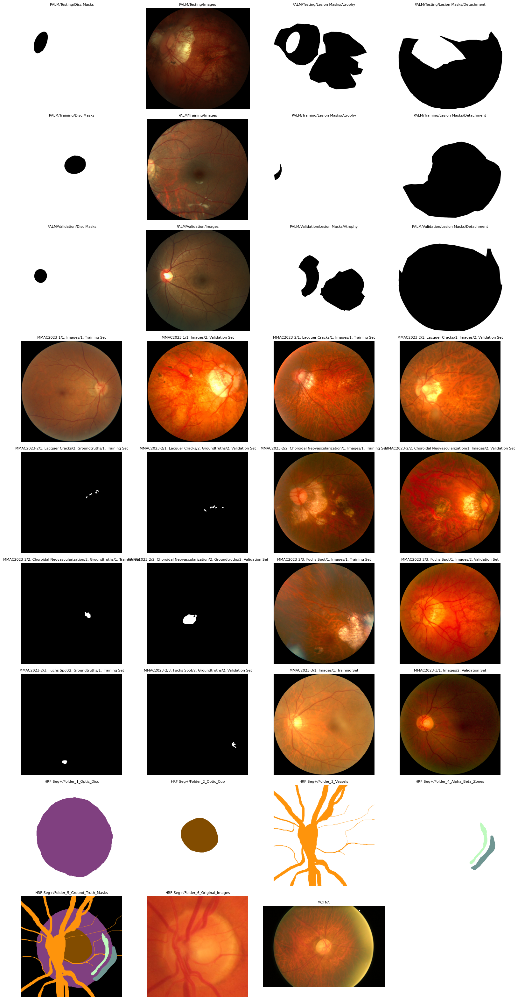

In [11]:
examples = []
for name, root in DATASET_DIRS.items():
    if root is None:
        continue
    folders = {}
    for p in sorted(root.rglob('*')):
        if p.suffix.lower() in IMG_EXT:
            folders.setdefault(p.parent, []).append(p)
    examples += [(f'{name}/{folder.relative_to(root)}', files[0]) for folder, files in folders.items()]

if examples:
    cols = 4
    rows = (len(examples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows), squeeze=False)
    for ax in axes.ravel():
        ax.axis('off')
    for ax, (title, p) in zip(axes.ravel(), examples):
        ax.imshow(Image.open(p), cmap='gray')
        ax.set_title(title, fontsize=8)
    plt.tight_layout()
    plt.show()

## 9. Dataset harmonization and task-specific labels
All datasets are mapped into one table (`meta`), one row per image.

- `pm_label`: 1 = PM, 0 = non-PM, `None` = unknown. Decide per dataset and write the rule down. (A common convention for MMAC-style grades is PM = grade 2 or worse; confirm it matches your definition.)
- `severity`: 0-4 in the order of `SEVERITY_NAMES`, `None` if the dataset has no severity.
- `fovea_x`, `fovea_y`: pixel coordinates in the **original** image.
- `mask_*`: path to the mask file, `None` if no mask exists.

In [12]:
SEG_TASKS = ['disc', 'atrophy', 'lesion_lc', 'lesion_cnv', 'lesion_fs', 'tessellation']
SEG_COLORS = dict(zip(SEG_TASKS, ['lime', 'red', 'yellow', 'orange', 'magenta', 'cyan']))
SEVERITY_NAMES = ['No lesion', 'Tessellated fundus', 'Diffuse atrophy', 'Patchy atrophy', 'Macular atrophy']
COLUMNS = (['dataset', 'source_id', 'image_path', 'pm_label', 'severity', 'fovea_x', 'fovea_y']
           + [f'mask_{t}' for t in SEG_TASKS])

# How raw mask pixels become a 0/1 mask. Default: any non-zero pixel (alpha channel ignored).
def _gray(m):
    m = m[..., :3] if m.ndim == 3 else m
    return m if m.ndim == 2 else m.max(2)

default_rule = lambda m: _gray(m) > 0

def relative_rule(m):
    # works for 0/1, 0/255 and colour-coded masks; ignores faint compression noise
    g = _gray(m)
    return (g > 0.5 * g.max()) if g.max() > 0 else np.zeros(g.shape, bool)

MASK_RULES = {('HRF-Seg+', 'disc'): relative_rule}

def index_by_stem(folder):
    return {p.stem: p for p in sorted(Path(folder).rglob('*')) if p.is_file() and p.suffix.lower() in IMG_EXT}

**[FILL AFTER INSPECTION] PALM.** One dict per image with the keys in `COLUMNS`. Use `None` where PALM has no annotation. `source_id` = patient id if it exists, otherwise a unique image id.

In [13]:
from collections import defaultdict

PALM_ROOT = DATASET_DIRS['PALM']
PALM_SPLITS = ['Training', 'Validation', 'Testing']      # official folders; all three are used, section 13 re-splits

# Disc / atrophy mask folders were not visible in the inspection (folder list truncated).
# Empty = those masks stay missing. To enable, list the folder(s), e.g. {'disc': [PALM_ROOT / 'Training' / '<disc folder>']}.
# Masks are matched to images by file stem.
PALM_MASK_DIRS = {'disc': [], 'atrophy': []}
palm_masks = {t: {} for t in PALM_MASK_DIRS}
for t, folders in PALM_MASK_DIRS.items():
    for f in folders:
        palm_masks[t].update(index_by_stem(f))

palm_rows, n_fovea_dropped = [], 0
for split in PALM_SPLITS:
    sdir = PALM_ROOT / split
    tbl = pd.read_excel(sdir / 'Classification Labels.xlsx').merge(
        pd.read_excel(sdir / 'Fovea Localization.xlsx'), on='imgName', how='left', validate='one_to_one')
    wanted = set(tbl.imgName)
    found = defaultdict(list)
    for p in sdir.rglob('*'):
        if p.is_file() and p.name in wanted:
            found[p.name].append(p)

    for r in tbl.itertuples(index=False):
        paths = found.get(r.imgName, [])
        assert len(paths) == 1, f'{r.imgName}: {len(paths)} matches {paths}'
        p = paths[0]
        fx, fy = r.Fovea_X, r.Fovea_Y
        if pd.notna(fx) and pd.notna(fy):
            with Image.open(p) as im:
                w, h = im.size
            if not (0 <= fx < w and 0 <= fy < h):          # outside the image -> unknown, not kept
                fx = fy = np.nan
                n_fovea_dropped += 1
        else:
            fx = fy = np.nan
        row = dict(dataset='PALM', source_id=f'PALM|{r.imgName}', image_path=str(p),
                   pm_label=int(r.Label) if pd.notna(r.Label) else None,     # severity: not in PALM -> unknown
                   fovea_x=fx, fovea_y=fy)
        for t in PALM_MASK_DIRS:
            m = palm_masks[t].get(Path(r.imgName).stem)
            row[f'mask_{t}'] = str(m) if m is not None else None
        palm_rows.append(row)

palm_df = pd.DataFrame(palm_rows, columns=COLUMNS)
print(len(palm_df), 'PALM images | fovea outside image (set unknown):', n_fovea_dropped)
print('annotated:', {'pm_label': int(palm_df.pm_label.notna().sum()), 'fovea': int(palm_df.fovea_x.notna().sum()),
                     'mask_disc': int(palm_df.mask_disc.notna().sum()), 'mask_atrophy': int(palm_df.mask_atrophy.notna().sum())})
# Check that Label 1 means PM: file-name prefix vs label (the label meaning is not stated in the tables)
print(pd.crosstab(palm_df.source_id.str.split('|').str[1].str[0].rename('prefix'), palm_df.pm_label.rename('Label')))

1200 PALM images | fovea outside image (set unknown): 0
annotated: {'pm_label': 1200, 'fovea': 1200, 'mask_disc': 0, 'mask_atrophy': 0}
Label     0    1
prefix          
H        26    0
N       161    0
P         0  213
T       187  213
V       189  211


**[FILL AFTER INSPECTION] MMAC 2023.**

In [14]:
MMAC_PM_MIN_GRADE = 2             # None: MMAC pm_label stays unknown. 2 would mean PM = grade >= 2 (a definition choice, not in the data)
MMAC_GROUP_BY_DEMOGRAPHICS = False   # True: images with equal age/sex/height/weight/centre share a source_id (proxy for same patient)

def mmac_source_id(r, image):
    if MMAC_GROUP_BY_DEMOGRAPHICS:
        return 'MMAC|' + '|'.join(str(getattr(r, c)) for c in ['age', 'sex', 'height', 'weight', 'data_center'])
    return f'MMAC|{image}'

def one_csv(folder, pattern):
    hits = sorted(Path(folder).glob(pattern))
    assert len(hits) == 1, f'{pattern} in {folder}: {hits}'
    return hits[0]

mmac_rows = []

# Task 1: severity grade (MMAC grades 0-4 map to SEVERITY_NAMES in order)
T1 = DATASET_DIRS['MMAC2023-1']
n_absent = 0
for split, sfolder in [('Training', '1. Training Set'), ('Validation', '2. Validation Set')]:
    tbl = pd.read_csv(one_csv(T1 / '2. Groundtruths', f'*Classification_{split}_Labels.csv'))
    for r in tbl.itertuples(index=False):
        p = T1 / '1. Images' / sfolder / r.image
        if not p.exists():
            n_absent += 1
            continue
        grade = int(r.myopic_maculopathy_grade) if pd.notna(r.myopic_maculopathy_grade) else None
        pm = None if (grade is None or MMAC_PM_MIN_GRADE is None) else int(grade >= MMAC_PM_MIN_GRADE)
        mmac_rows.append(dict(dataset='MMAC2023', source_id=mmac_source_id(r, r.image), image_path=str(p),
                              pm_label=pm, severity=grade))        # fovea and masks: not in task 1 -> unknown
print('task 1:', len(mmac_rows), 'images | listed in CSV but file missing:', n_absent)

# Task 2: one lesion type per image; the other lesion types on that image are unknown, so each type is its own mask
T2 = DATASET_DIRS['MMAC2023-2']
LESIONS = [('1. Lacquer Cracks', 'Lacquer_Cracks', 'lesion_lc'),
           ('2. Choroidal Neovascularization', 'Choroidal_Neovascularization', 'lesion_cnv'),
           ('3. Fuchs Spot', 'Fuchs_Spot', 'lesion_fs')]
for lfolder, suffix, task in LESIONS:
    n_img = n_mask = n_absent = 0
    for split, sfolder in [('Training', '1. Training Set'), ('Validation', '2. Validation Set')]:
        gt = T2 / lfolder / '2. Groundtruths'
        tbl = pd.read_csv(one_csv(gt, f'*Segmentation_{split}_Images_{suffix}.csv'))
        masks = index_by_stem(gt / sfolder)
        for r in tbl.itertuples(index=False):
            p = T2 / lfolder / '1. Images' / sfolder / r.image
            if not p.exists():
                n_absent += 1
                continue
            m = masks.get(Path(r.image).stem)
            n_img += 1
            n_mask += m is not None
            mmac_rows.append(dict(dataset='MMAC2023', source_id=mmac_source_id(r, r.image), image_path=str(p),
                                  **{f'mask_{task}': str(m) if m is not None else None}))
    print(f'{task}: {n_img} images, {n_mask} masks matched by file name, {n_absent} listed but missing')
    if n_img and n_mask == 0:
        print('   no masks matched; first files in the mask folder:', [q.name for q in list((T2 / lfolder / '2. Groundtruths' / '1. Training Set').rglob('*'))[:5]])

# Task 3 (spherical equivalent) is not used: no task in this notebook needs it.
mmac_df = pd.DataFrame(mmac_rows, columns=COLUMNS)
print('severity values:', mmac_df.severity.value_counts(dropna=False).sort_index().to_dict())

task 1: 1391 images | listed in CSV but file missing: 0
lesion_lc: 75 images, 75 masks matched by file name, 0 listed but missing
lesion_cnv: 39 images, 39 masks matched by file name, 0 listed but missing
lesion_fs: 67 images, 67 masks matched by file name, 0 listed but missing
severity values: {0.0: 484, 1.0: 490, 2.0: 289, 3.0: 72, 4.0: 56, nan: 181}


**HRF-Seg+** (replaces HPMI). Optic disc masks from `Folder_1_Optic_Disc`, matched to `Folder_6_Original_Images` by file name. No PM label, severity or fovea, so those stay unknown. Cup, vessel and alpha/beta zone masks exist but have no task here.

In [15]:
HRF_ROOT = DATASET_DIRS['HRF-Seg+']
hrf_images = sorted(p for p in (HRF_ROOT / 'Folder_6_Original_Images').rglob('*')
                    if p.is_file() and p.suffix.lower() in IMG_EXT)
hrf_disc = index_by_stem(HRF_ROOT / 'Folder_1_Optic_Disc')

hrf_rows = [dict(dataset='HRF-Seg+', source_id=f'HRF-Seg+|{p.stem}', image_path=str(p),
                 mask_disc=str(hrf_disc[p.stem]) if p.stem in hrf_disc else None)
            for p in hrf_images]
hrf_df = pd.DataFrame(hrf_rows, columns=COLUMNS)
print(len(hrf_df), 'HRF-Seg+ images |', int(hrf_df.mask_disc.notna().sum()), 'disc masks matched by file name')
if len(hrf_df) and hrf_df.mask_disc.notna().sum() == 0:
    print('no masks matched; first mask files:', [q.name for q in list(hrf_disc.values())[:5]], '| first images:', [p.name for p in hrf_images[:5]])

45 HRF-Seg+ images | 45 disc masks matched by file name


**[FILL AFTER INSPECTION] MCTN Fundus.**

In [16]:
# No annotation table was found for MCTN, so every label is unknown. The images join the pool but add nothing to supervised losses.
mctn_rows = [dict(dataset='MCTN', source_id=f'MCTN|{p.stem}', image_path=str(p))
             for p in sorted(DATASET_DIRS['MCTN'].rglob('*')) if p.is_file() and p.suffix.lower() in IMG_EXT]
mctn_df = pd.DataFrame(mctn_rows, columns=COLUMNS)
print(len(mctn_df), 'MCTN images, all labels unknown')

289 MCTN images, all labels unknown


Combine and validate. The unique id is built from the relative path so it stays the same between sessions.

In [17]:
meta = pd.concat([palm_df, mmac_df, hrf_df, mctn_df], ignore_index=True)
assert len(meta) > 0, 'Fill the four dataset cells above first.'

# None -> NaN so unknown labels are numeric-missing, never 0
for c in ['pm_label', 'severity', 'fovea_x', 'fovea_y']:
    meta[c] = pd.to_numeric(meta[c])

meta['uid'] = [f'{d}|{Path(p).relative_to(INPUT_DIR)}' for d, p in zip(meta.dataset, meta.image_path)]
mask_cols = [f'mask_{t}' for t in SEG_TASKS]

assert meta.uid.is_unique, 'duplicate image rows'
assert all(Path(p).exists() for p in meta.image_path), 'missing image file'
for c in mask_cols:
    assert all(Path(p).exists() for p in meta[c].dropna()), f'missing file in {c}'
assert set(meta.pm_label.dropna().unique()) <= {0, 1}
assert set(meta.severity.dropna().unique()) <= set(range(len(SEVERITY_NAMES)))
print(len(meta), 'images |', meta.dataset.value_counts().to_dict())

3106 images | {'MMAC2023': 1572, 'PALM': 1200, 'MCTN': 289, 'HRF-Seg+': 45}


## 10. Missing labels and unavailable annotations
Each task has its own availability. Losses later use a mask so absent annotations contribute nothing.

          PM label  Severity  Fovea  Mask: disc  Mask: atrophy  Mask: lesion_lc  Mask: lesion_cnv  Mask: lesion_fs  Mask: tessellation  total images
dataset                                                                                                                                             
HRF-Seg+         0         0      0          45              0                0                 0                0                   0            45
MCTN             0         0      0           0              0                0                 0                0                   0           289
MMAC2023      1391      1391      0           0              0               75                39               67                   0          1572
PALM          1200         0   1200           0              0                0                 0                0                   0          1200


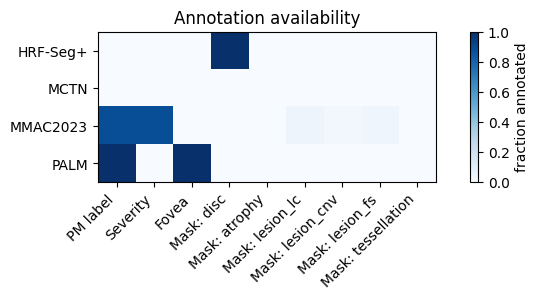

In [18]:
avail = pd.DataFrame({'PM label': meta.pm_label.notna(),
                      'Severity': meta.severity.notna(),
                      'Fovea': meta.fovea_x.notna() & meta.fovea_y.notna(),
                      **{f'Mask: {t}': meta[f'mask_{t}'].notna() for t in SEG_TASKS}})
counts = avail.groupby(meta.dataset).sum()
counts['total images'] = meta.dataset.value_counts()
print(counts.to_string())

frac = avail.groupby(meta.dataset).mean()
plt.figure(figsize=(8, 3))
plt.imshow(frac.values, cmap='Blues', vmin=0, vmax=1)
plt.xticks(range(frac.shape[1]), frac.columns, rotation=45, ha='right')
plt.yticks(range(frac.shape[0]), frac.index)
plt.colorbar(label='fraction annotated')
plt.title('Annotation availability')
plt.tight_layout()
plt.show()

## 11. Class distribution and basic EDA

pm_label  0.0  1.0  missing
dataset                    
HRF-Seg+    0    0       45
MCTN        0    0      289
MMAC2023  974  417      181
PALM      563  637        0 

 severity  0.0  1.0  2.0  3.0  4.0  missing
dataset                                   
HRF-Seg+    0    0    0    0    0       45
MCTN        0    0    0    0    0      289
MMAC2023  484  490  289   72   56      181
PALM        0    0    0    0    0     1200


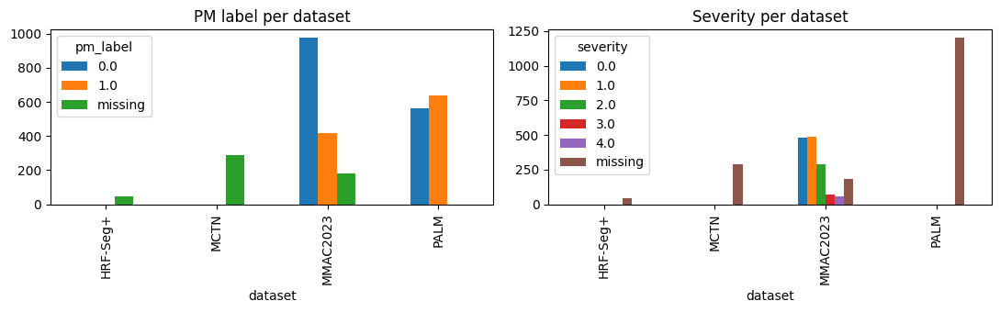

In [19]:
pm_ct = pd.crosstab(meta.dataset, meta.pm_label.fillna('missing'))
sev_ct = pd.crosstab(meta.dataset, meta.severity.fillna('missing'))
print(pm_ct, '\n\n', sev_ct)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
pm_ct.plot.bar(ax=ax[0], title='PM label per dataset')
sev_ct.plot.bar(ax=ax[1], title='Severity per dataset')
plt.tight_layout()
plt.show()

In [20]:
meta['orig_w'], meta['orig_h'] = zip(*[Image.open(p).size for p in meta.image_path])
meta.groupby('dataset')[['orig_w', 'orig_h']].describe().T

dataset       HRF-Seg+    MCTN  MMAC2023         PALM
orig_w count      45.0   289.0    1572.0  1200.000000
       mean      500.0  3072.0     800.0  2037.300000
       std         0.0     0.0       0.0   226.896478
       min       500.0  3072.0     800.0  1444.000000
       25%       500.0  3072.0     800.0  2124.000000
       50%       500.0  3072.0     800.0  2124.000000
       75%       500.0  3072.0     800.0  2124.000000
       max       500.0  3072.0     800.0  2124.000000
orig_h count      45.0   289.0    1572.0  1200.000000
       mean      500.0  2048.0     800.0  1977.970000
       std         0.0     0.0       0.0   204.206830
       min       500.0  2048.0     800.0  1444.000000
       25%       500.0  2048.0     800.0  2056.000000
       50%       500.0  2048.0     800.0  2056.000000
       75%       500.0  2048.0     800.0  2056.000000
       max       500.0  2048.0     800.0  2056.000000

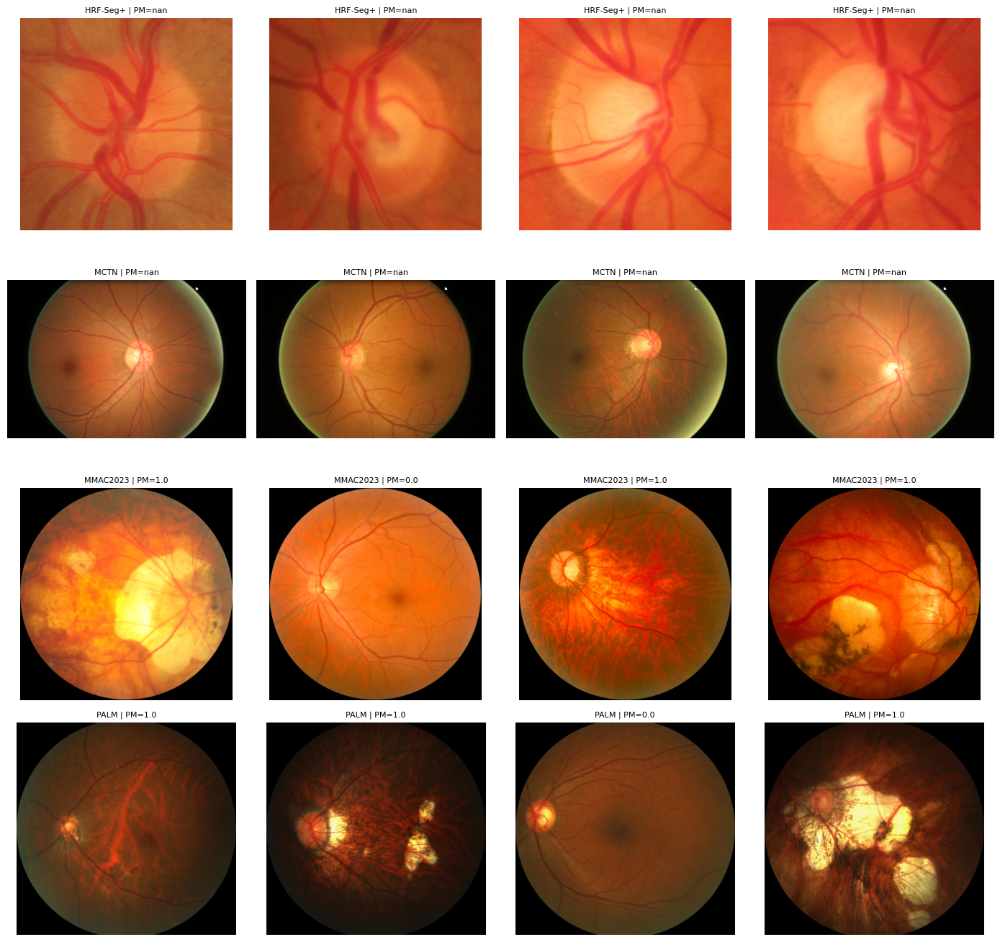

In [21]:
sample = meta.groupby('dataset', group_keys=False).apply(lambda g: g.sample(min(4, len(g)), random_state=SEED))
datasets = list(sample.dataset.unique())
fig, axes = plt.subplots(len(datasets), 4, figsize=(14, 3.3 * len(datasets)), squeeze=False)
for ax in axes.ravel():
    ax.axis('off')
for i, ds in enumerate(datasets):
    for j, r in enumerate(sample[sample.dataset == ds].itertuples()):
        axes[i, j].imshow(Image.open(r.image_path))
        axes[i, j].set_title(f'{ds} | PM={r.pm_label}', fontsize=8)
plt.tight_layout()
plt.show()

## 12. Duplicate and leakage checks
Exact duplicates (file hash) are grouped so they can never land in different splits. Near-duplicates (image hash) are only reported for manual review, because fundus images look alike and hashes can collide.

In [22]:
HASH_FILE = DIRS['splits'] / 'hashes.csv'

def file_md5(p):
    with open(p, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def dhash(p):
    g = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    g = cv2.resize(g, (17, 16), interpolation=cv2.INTER_AREA)
    return np.packbits((g[:, 1:] > g[:, :-1]).flatten()).tobytes().hex()

if HASH_FILE.exists():
    meta = meta.merge(pd.read_csv(HASH_FILE), on='uid', how='left')
else:
    meta['md5'] = [file_md5(p) for p in tqdm(meta.image_path)]
    meta['dhash'] = [dhash(p) for p in tqdm(meta.image_path)]
    meta[['uid', 'md5', 'dhash']].to_csv(HASH_FILE, index=False)

dup = meta[meta.duplicated('md5', keep=False)]
print('images sharing an identical file:', len(dup), '| groups:', dup.md5.nunique())
print(dup.groupby('md5').dataset.nunique().value_counts().rename('datasets per duplicate group').to_string())

near = meta[meta.duplicated('dhash', keep=False) & ~meta.duplicated('md5', keep=False)]
print('near-duplicate candidates (same dhash, different file):', len(near))

  0%|          | 0/3106 [00:00<?, ?it/s]

  0%|          | 0/3106 [00:00<?, ?it/s]

images sharing an identical file: 121 | groups: 60
dataset
1    60
near-duplicate candidates (same dhash, different file): 82


`group_id` joins images of the same source (patient) and images with identical files, so a split by group cannot leak.

In [23]:
key = meta.dataset + '|' + meta.source_id.astype(str)
k_codes = pd.factorize(key)[0]
m_codes = pd.factorize(meta.md5)[0]
n, nk, nm = len(meta), k_codes.max() + 1, m_codes.max() + 1
rows = np.r_[np.arange(n), np.arange(n)]
cols = np.r_[n + k_codes, n + nk + m_codes]
graph = coo_matrix((np.ones(2 * n), (rows, cols)), shape=(n + nk + nm, n + nk + nm))
_, component = connected_components(graph, directed=False)
meta['group_id'] = component[:n]
print(n, 'images in', meta.group_id.nunique(), 'groups')

3106 images in 3045 groups


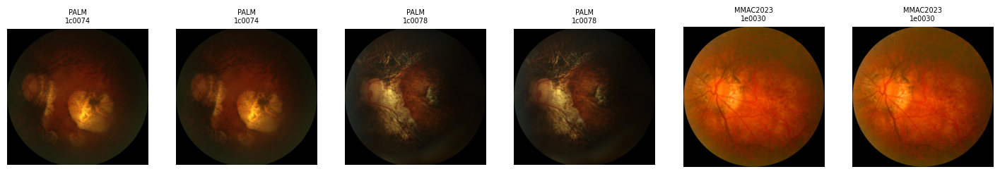

In [24]:
if len(near):
    pairs = near.sort_values('dhash').head(6)
    fig, axes = plt.subplots(1, len(pairs), figsize=(3 * len(pairs), 3), squeeze=False)
    for ax, r in zip(axes[0], pairs.itertuples()):
        ax.imshow(Image.open(r.image_path))
        ax.set_title(f'{r.dataset}\n{r.dhash[:6]}', fontsize=7)
        ax.axis('off')
    plt.show()

## 13. Train / validation / test split
70 / 15 / 15, grouped by `group_id`, stratified by dataset and PM label. The split is saved once and reloaded in later sessions, so the benchmark split never changes.

In [25]:
SPLIT_FILE = DIRS['splits'] / 'split.csv'

if SPLIT_FILE.exists():
    meta = meta.merge(pd.read_csv(SPLIT_FILE)[['uid', 'split']], on='uid', how='left')
    assert meta.split.notna().all(), 'saved split does not cover all images'
else:
    strat = meta.dataset + '_' + meta.pm_label.fillna(-1).astype(str)
    sgkf = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=SEED)
    fold = np.zeros(len(meta), dtype=int)
    for i, (_, idx) in enumerate(sgkf.split(meta, strat, meta.group_id)):
        fold[idx] = i
    meta['split'] = np.where(fold < 3, 'test', np.where(fold < 6, 'val', 'train'))
    meta[['uid', 'group_id', 'split']].to_csv(SPLIT_FILE, index=False)

assert meta.groupby('group_id').split.nunique().max() == 1, 'a group is split across sets'
print(meta.split.value_counts(normalize=True).round(3).to_dict())
meta.groupby(['split', 'dataset']).pm_label.agg(n='size', pm_positive='sum')

{'train': 0.695, 'val': 0.153, 'test': 0.152}


n  pm_positive
split dataset                    
test  HRF-Seg+     5          0.0
      MCTN        45          0.0
      MMAC2023   236         62.0
      PALM       187         92.0
train HRF-Seg+    34          0.0
      MCTN       197          0.0
      MMAC2023  1098        288.0
      PALM       830        445.0
val   HRF-Seg+     6          0.0
      MCTN        47          0.0
      MMAC2023   238         67.0
      PALM       183        100.0

## 14. Image preprocessing
Crop the black border, resize to a square, apply CLAHE on the lightness channel. Done once and cached.
448 px (diagram: 512) is chosen because it is divisible by 16, 32 and by the Swin window, so all six models run without architecture changes. Lower it if memory runs out, but keep it identical for all models.

In [26]:
IMG_SIZE = 224
BG_THRESH = 15          # grey level below which a pixel counts as background; check visually below
CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def read_rgb(p):
    return cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)

def read_mask(p, key, shape):
    raw = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    m = MASK_RULES.get(key, default_rule)(raw).astype(np.uint8)
    if m.shape != shape:
        m = cv2.resize(m, (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST)
    return m

def prep_row(r):
    img = read_rgb(r.image_path)
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    ys, xs = np.where(gray > BG_THRESH)
    x0, y0 = xs.min(), ys.min()
    bw, bh = xs.max() - x0 + 1, ys.max() - y0 + 1

    def crop_resize(a, interp):
        return cv2.resize(a[y0:y0 + bh, x0:x0 + bw], (IMG_SIZE, IMG_SIZE), interpolation=interp)

    stem = hashlib.md5(r.uid.encode()).hexdigest()[:16]
    lab = cv2.cvtColor(crop_resize(img, cv2.INTER_AREA), cv2.COLOR_RGB2LAB)
    lab[..., 0] = CLAHE.apply(lab[..., 0])
    cv2.imwrite(str(PREP_DIR / f'{stem}.jpg'), cv2.cvtColor(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB), cv2.COLOR_RGB2BGR),
                [cv2.IMWRITE_JPEG_QUALITY, 95])
    cv2.imwrite(str(PREP_DIR / f'{stem}_fundus.png'), crop_resize((gray > BG_THRESH).astype(np.uint8), cv2.INTER_NEAREST) * 255)
    out = {'uid': r.uid, 'prep_image': str(PREP_DIR / f'{stem}.jpg'), 'prep_fundus': str(PREP_DIR / f'{stem}_fundus.png'),
           'crop_x0': x0, 'crop_y0': y0, 'crop_w': bw, 'crop_h': bh}

    for t in SEG_TASKS:
        p = getattr(r, f'mask_{t}')
        if pd.notna(p):
            m = read_mask(p, (r.dataset, t), (h, w))
            cv2.imwrite(str(PREP_DIR / f'{stem}_{t}.png'), crop_resize(m, cv2.INTER_NEAREST) * 255)
            out[f'prep_{t}'] = str(PREP_DIR / f'{stem}_{t}.png')
        else:
            out[f'prep_{t}'] = None

    ok = pd.notna(r.fovea_x) and pd.notna(r.fovea_y)
    out['fovea_x_n'] = (r.fovea_x - x0) / bw if ok else np.nan
    out['fovea_y_n'] = (r.fovea_y - y0) / bh if ok else np.nan
    return out

PREP_META = DIRS['splits'] / 'meta_prep.csv'
reuse = PREP_META.exists()
if reuse:
    cached = pd.read_csv(PREP_META)
    reuse = set(cached.uid) == set(meta.uid) and all(Path(p).exists() for p in cached.prep_image)

if reuse:
    meta_prep = cached
else:
    prep = pd.DataFrame([prep_row(r) for r in tqdm(list(meta.itertuples()))])
    meta_prep = meta.merge(prep, on='uid')
    meta_prep.to_csv(PREP_META, index=False)
print(len(meta_prep), 'images preprocessed')

  0%|          | 0/3106 [00:00<?, ?it/s]

3106 images preprocessed


Visual check: original vs processed, with the fovea (if annotated) and any masks. Adjust `BG_THRESH` or `MASK_RULES` if something looks wrong, then delete `meta_prep.csv` and rerun.

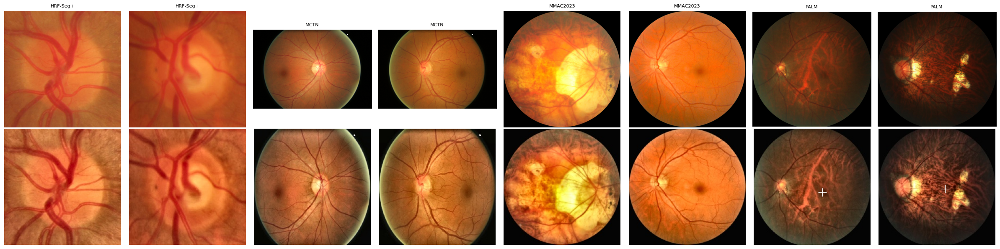

In [27]:
chk = meta_prep.groupby('dataset', group_keys=False).apply(lambda g: g.sample(min(2, len(g)), random_state=SEED))
fig, axes = plt.subplots(2, len(chk), figsize=(3 * len(chk), 6), squeeze=False)
for i, r in enumerate(chk.itertuples()):
    axes[0, i].imshow(read_rgb(r.image_path))
    axes[0, i].set_title(r.dataset, fontsize=8)
    axes[1, i].imshow(read_rgb(r.prep_image))
    for t in SEG_TASKS:
        if isinstance(getattr(r, f'prep_{t}'), str):
            axes[1, i].contour(cv2.imread(getattr(r, f'prep_{t}'), 0) > 127, levels=[0.5], colors=SEG_COLORS[t], linewidths=1)
    if pd.notna(r.fovea_x_n):
        axes[1, i].plot(r.fovea_x_n * IMG_SIZE, r.fovea_y_n * IMG_SIZE, 'w+', markersize=14)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

## 15. Data augmentation (training only)
Mild, anatomy-preserving changes: flip, small rotation, brightness/contrast. Same normalization for all models.

In [28]:
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_tf = A.Compose([A.HorizontalFlip(p=0.5),
                      A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.5),
                      A.RandomBrightnessContrast(0.1, 0.1, p=0.5),
                      A.Normalize(MEAN, STD), ToTensorV2()])
eval_tf = A.Compose([A.Normalize(MEAN, STD), ToTensorV2()])

## 16. Dataset classes and DataLoaders
Baseline task: PM vs non-PM on every image that has a PM label.

In [29]:
class FundusDataset(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True)
        self.tf = tf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = self.tf(image=read_rgb(r.prep_image))['image']
        return img, torch.tensor(r.pm_label, dtype=torch.float32)

BATCH_SIZE = 16
NUM_WORKERS = 4

cls_df = meta_prep[meta_prep.pm_label.notna()]
train_df, val_df, test_df = [cls_df[cls_df.split == s].reset_index(drop=True) for s in ['train', 'val', 'test']]
y_train = train_df.pm_label.values

g = torch.Generator()
g.manual_seed(SEED)
loader_args = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True, worker_init_fn=seed_worker)
train_loader = DataLoader(FundusDataset(train_df, train_tf), shuffle=True, drop_last=True, generator=g, **loader_args)
train_eval_loader = DataLoader(FundusDataset(train_df, eval_tf), shuffle=False, **loader_args)
val_loader = DataLoader(FundusDataset(val_df, eval_tf), shuffle=False, **loader_args)
test_loader = DataLoader(FundusDataset(test_df, eval_tf), shuffle=False, **loader_args)

print({'train': len(train_df), 'val': len(val_df), 'test': len(test_df)})
print('PM prevalence (train / val / test):', [round(d.pm_label.mean(), 3) for d in (train_df, val_df, test_df)])

{'train': 1804, 'val': 391, 'test': 396}
PM prevalence (train / val / test): [np.float64(0.406), np.float64(0.427), np.float64(0.389)]


## 17. Model selection
Three CNNs and three Transformers from timm, all with one output logit (PM probability). RETFound is a ViT-Large pretrained on retinal images; its weights are not in timm, so attach the checkpoint as a Kaggle input and set the path below.

In [30]:
RETFOUND_CKPT = Path(
    "/kaggle/input/datasets/kabhishekk1/retfound-cfp-weights/RETFound_cfp_weights.pth"
)  # [FILL] colour-fundus RETFound weights

MODEL_ZOO = {
    'ResNet-50':       dict(timm='resnet50', kind='cnn'),
    'DenseNet-121':    dict(timm='densenet121', kind='cnn'),
    'EfficientNet-B4': dict(timm='efficientnet_b4', kind='cnn'),
    'ViT-B/16':        dict(timm='vit_base_patch16_224', kind='vit', img_size=IMG_SIZE),
    'Swin-Tiny':       dict(timm='swin_tiny_patch4_window7_224', kind='swin', img_size=IMG_SIZE),
    'RETFound':        dict(timm='vit_large_patch16_224', kind='vit', img_size=IMG_SIZE, global_pool='avg'),
}

def load_retfound(model, path):
    ckpt = torch.load(path, map_location='cpu', weights_only=False)      # trusted source only
    state = ckpt.get('model', ckpt)
    state = {k: v for k, v in state.items() if not k.startswith('head')}
    if 'pos_embed' in state:
        state['pos_embed'] = resample_abs_pos_embed(state['pos_embed'], new_size=(IMG_SIZE // 16, IMG_SIZE // 16), num_prefix_tokens=1)
    result = model.load_state_dict(state, strict=False)
    print('RETFound loaded | missing:', result.missing_keys, '| unexpected:', result.unexpected_keys)

def build_model(name, drop=0.0, pretrained=True, weights=None):
    cfg = MODEL_ZOO[name]
    args = dict(num_classes=1, drop_rate=drop)
    for k in ['img_size', 'global_pool']:
        if k in cfg:
            args[k] = cfg[k]
    if name == 'RETFound':
        model = timm.create_model(cfg['timm'], pretrained=False, **args)
        if pretrained:
            load_retfound(model, RETFOUND_CKPT)
        return model
    return timm.create_model(weights or cfg['timm'], pretrained=pretrained, **args)

Sanity check: parameter count and output shape for each model at the chosen resolution. If a model fails to build at `IMG_SIZE`, fix it here and keep the size identical for all six.

In [31]:
rows = []
for name in MODEL_ZOO:
    m = build_model(name, pretrained=False).to(DEVICE).eval()
    with torch.no_grad():
        out = m(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE))
    rows.append(dict(model=name, timm=MODEL_ZOO[name]['timm'], params_M=round(sum(p.numel() for p in m.parameters()) / 1e6, 1), output=tuple(out.shape)))
    del m
    torch.cuda.empty_cache()
pd.DataFrame(rows)

,model,timm,params_M,output
0,ResNet-50,resnet50,23.5,"(1, 1)"
1,DenseNet-121,densenet121,7.0,"(1, 1)"
2,EfficientNet-B4,efficientnet_b4,17.6,"(1, 1)"
3,ViT-B/16,vit_base_patch16_224,85.8,"(1, 1)"
4,Swin-Tiny,swin_tiny_patch4_window7_224,27.5,"(1, 1)"
5,RETFound,vit_large_patch16_224,303.3,"(1, 1)"


## 19-21. Shared baseline setup, loss, optimizer, scheduler, hyperparameters
Identical for all six models: same split, resolution, augmentation, seed, optimizer, scheduler, epochs and early stopping. The loss is plain BCE; class-imbalance handling is left for the optimization stage.
Keys below the first line are optimization switches. They are **off** in the baseline and only the improvement stage changes them.

In [32]:
BASE_CFG = dict(seed=SEED, epochs=15, batch_size=BATCH_SIZE, lr=1e-4, weight_decay=1e-2, drop=0.0, patience=4, grad_clip=1.0,
                loss='bce', head_lr_mult=1.0, freeze_epochs=0, kd_alpha=0.0, kd_T=2.0, arch='plain', weights=None)
print(json.dumps(BASE_CFG, indent=1))

{
 "seed": 42,
 "epochs": 15,
 "batch_size": 16,
 "lr": 0.0001,
 "weight_decay": 0.01,
 "drop": 0.0,
 "patience": 4,
 "grad_clip": 1.0,
 "loss": "bce",
 "head_lr_mult": 1.0,
 "freeze_epochs": 0,
 "kd_alpha": 0.0,
 "kd_T": 2.0,
 "arch": "plain",
 "weights": null
}


## 23. Metrics
AUROC and AUPRC need probabilities; F1, precision, recall, sensitivity, specificity need a threshold. During training the threshold is 0.5; for final reporting it is chosen on the **validation** set (Youden index) and applied to test. ECE measures calibration.

In [49]:
def classification_metrics(y, p, thr=0.5):
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return dict(auroc=roc_auc_score(y, p), auprc=average_precision_score(y, p),
                f1=f1_score(y, pred, zero_division=0), precision=precision_score(y, pred, zero_division=0),
                recall=recall_score(y, pred, zero_division=0),
                sensitivity=tp / max(tp + fn, 1), specificity=tn / max(tn + fp, 1))

def ece_score(y, p, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = (p > lo) & (p <= hi)
        if in_bin.any():
            ece += in_bin.mean() * abs(y[in_bin].mean() - p[in_bin].mean())
    return ece

@torch.no_grad()
def predict(model, loader):
    model.eval()
    ys, ps = [], []

    for batch_idx, (x, y) in enumerate(loader):

        x = x.to(DEVICE, non_blocking=True)

        # Check input first
        if not torch.isfinite(x).all():
            bad = ~torch.isfinite(x)
            print(
                f"BAD INPUT at batch {batch_idx} | "
                f"NaN/Inf count = {bad.sum().item()} | "
                f"min={torch.nan_to_num(x).min().item():.4f} | "
                f"max={torch.nan_to_num(x).max().item():.4f}"
            )
            raise RuntimeError("Non-finite input detected.")

        # For diagnosis, disable AMP during evaluation
        logit = model(x).squeeze(1).float()

        if not torch.isfinite(logit).all():
            bad = ~torch.isfinite(logit)

            print(
                f"NON-FINITE OUTPUT at batch {batch_idx} | "
                f"bad values = {bad.sum().item()} | "
                f"min={torch.nan_to_num(logit).min().item():.4f} | "
                f"max={torch.nan_to_num(logit).max().item():.4f}"
            )

            raise RuntimeError(
                f"Non-finite model output at batch {batch_idx}"
            )

        p = torch.sigmoid(logit)

        if not torch.isfinite(p).all():
            raise RuntimeError(
                f"Non-finite probability at batch {batch_idx}"
            )

        ys.append(y.cpu())
        ps.append(p.cpu())

    y = torch.cat(ys).numpy()
    p = torch.cat(ps).numpy()

    p = np.clip(p, 1e-6, 1 - 1e-6)

    loss = F.binary_cross_entropy(
        torch.tensor(p, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    ).item()

    return y, p, loss

## 22, 24-27. Training loop
Per epoch: train, validate, log loss / learning rate / metrics / time, step the cosine scheduler, keep the best epoch by validation AUROC, stop early after `patience` epochs without improvement. The best weights are saved as `best.pth`; predictions and a `results.json` are written next to it.

In [34]:
def classification_loss(logit, y, cfg, pos_weight, teacher_logit=None):
    if cfg['loss'] == 'focal':
        bce = F.binary_cross_entropy_with_logits(logit, y, reduction='none')
        loss = ((1 - torch.exp(-bce)) ** 2 * bce).mean()
    else:
        pw = pos_weight if cfg['loss'] == 'pos_weight' else None
        loss = F.binary_cross_entropy_with_logits(logit, y, pos_weight=pw)
    if teacher_logit is not None:
        T = cfg['kd_T']
        soft = torch.sigmoid(teacher_logit / T)
        kd = F.binary_cross_entropy_with_logits(logit / T, soft) * T * T
        loss = (1 - cfg['kd_alpha']) * loss + cfg['kd_alpha'] * kd
    return loss

def train_model(model, cfg, out_dir, name, teacher=None):
    out_dir.mkdir(parents=True, exist_ok=True)
    set_seed(cfg['seed'])
    model = model.to(DEVICE)

    head_ids = {id(p) for p in model.get_classifier().parameters()}
    head = [p for p in model.parameters() if id(p) in head_ids]
    body = [p for p in model.parameters() if id(p) not in head_ids]
    optimizer = torch.optim.AdamW([{'params': body, 'lr': cfg['lr']},
                                   {'params': head, 'lr': cfg['lr'] * cfg['head_lr_mult']}],
                                  weight_decay=cfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
    pos_weight = torch.tensor(float((y_train == 0).sum() / (y_train == 1).sum()), device=DEVICE)

    history, best_auroc, best_epoch, wait = [], -1.0, 0, 0
    start = time.time()
    print(f'[{name}] start {time.strftime("%Y-%m-%d %H:%M:%S")}')

    for epoch in range(cfg['epochs']):
        t0 = time.time()
        for p in body:
            p.requires_grad = epoch >= cfg['freeze_epochs']
        model.train()
        running = 0.0
        for x, y in tqdm(train_loader, leave=False):
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            t_logit = None
            with torch.autocast(DEVICE.type, enabled=USE_AMP):
                logit = model(x).squeeze(1)
                if teacher is not None:
                    with torch.no_grad():
                        t_logit = teacher(x).squeeze(1).float()
            loss = classification_loss(logit.float(), y, cfg, pos_weight, t_logit)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            running += loss.item() * len(y)

        lr_now = optimizer.param_groups[0]['lr']
        scheduler.step()
        yv, pv, val_loss = predict(model, val_loader)
        m = classification_metrics(yv, pv)
        history.append(dict(epoch=epoch + 1, train_loss=running / len(train_df), val_loss=val_loss, lr=lr_now,
                            **{f'val_{k}': v for k, v in m.items()}, epoch_sec=time.time() - t0))
        print(f'epoch {epoch + 1:02d} | train {history[-1]["train_loss"]:.4f} | val {val_loss:.4f} | AUROC {m["auroc"]:.4f} | AUPRC {m["auprc"]:.4f} | {time.time() - t0:.0f}s')

        if m['auroc'] > best_auroc + 1e-4:
            best_auroc, best_epoch, wait = m['auroc'], epoch + 1, 0
            torch.save(model.state_dict(), out_dir / 'best.pth')
        else:
            wait += 1
            if wait >= cfg['patience']:
                print('early stopping')
                break

    model.load_state_dict(torch.load(out_dir / 'best.pth', map_location=DEVICE))
    yv, pv, _ = predict(model, val_loader)
    fpr, tpr, thr = roc_curve(yv, pv)
    threshold = float(thr[np.argmax(tpr - fpr)])

    res = dict(model=name, cfg=cfg, params_M=sum(p.numel() for p in model.parameters()) / 1e6, threshold=threshold,
               best_epoch=best_epoch, epochs_run=len(history), start=time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start)),
               end=time.strftime('%Y-%m-%d %H:%M:%S'), minutes=(time.time() - start) / 60)
    preds = []
    for split, loader, df in [('train', train_eval_loader, train_df), ('val', val_loader, val_df), ('test', test_loader, test_df)]:
        y, p, _ = predict(model, loader)
        res[split] = classification_metrics(y, p, threshold)
        if split == 'test':
            res['ece_test'] = ece_score(y, p)
        preds.append(pd.DataFrame(dict(uid=df.uid.values, dataset=df.dataset.values, split=split, y=y, prob=p)))

    pd.DataFrame(history).to_csv(out_dir / 'history.csv', index=False)
    pd.concat(preds).to_csv(out_dir / 'predictions.csv', index=False)
    json.dump(res, open(out_dir / 'results.json', 'w'), indent=1, default=float)
    print(f'[{name}] done in {res["minutes"]:.1f} min | best epoch {best_epoch}')
    del model
    torch.cuda.empty_cache()
    return res

## 28. Train all six baselines
One model at a time with identical settings. A finished model is skipped on rerun, so training can continue across sessions. Do not edit `BASE_CFG` or the data pipeline once this has started.

In [35]:
BASE_DIR = {name: DIRS['baseline'] / name.replace('/', '_') for name in MODEL_ZOO}

for name in MODEL_ZOO:
    if (BASE_DIR[name] / 'results.json').exists():
        print('already trained:', name)
        continue
    train_model(build_model(name, drop=BASE_CFG['drop']), BASE_CFG, BASE_DIR[name], name)

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

[ResNet-50] start 2026-10-06 11:49:26


  0%|          | 0/112 [00:00<?, ?it/s]

epoch 01 | train 0.5609 | val 0.3469 | AUROC 0.9719 | AUPRC 0.9674 | 11s


...

epoch 09 | train 0.0271 | val 0.2565 | AUROC 0.9842 | AUPRC 0.9847 | 61s


  0%|          | 0/112 [00:00<?, ?it/s]

epoch 10 | train 0.0162 | val 0.2940 | AUROC 0.9865 | AUPRC 0.9869 | 81s


  0%|          | 0/112 [00:00<?, ?it/s]

epoch 11 | train 0.0138 | val 0.3472 | AUROC 0.9849 | AUPRC 0.9849 | 61s
early stopping
[RETFound] done in 14.5 min | best epoch 7


In [36]:
from pathlib import Path

for p in Path("/kaggle/input").rglob("*"):
    if p.is_file() and "retfound" in p.name.lower():
        print("FOUND:", p)

FOUND: /kaggle/input/datasets/kabhishekk1/retfound-cfp-weights/RETFound_cfp_weights.pth


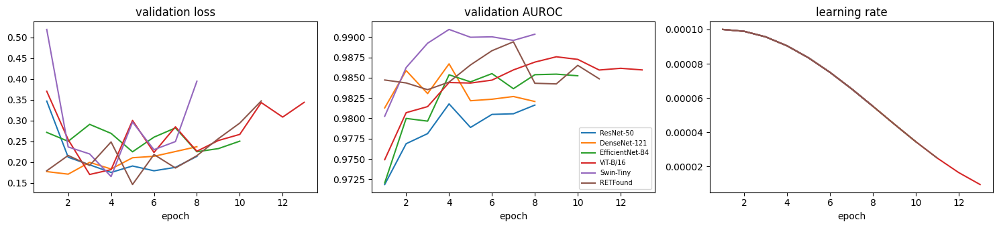

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for name in MODEL_ZOO:
    h = pd.read_csv(BASE_DIR[name] / 'history.csv')
    axes[0].plot(h.epoch, h.val_loss, label=name)
    axes[1].plot(h.epoch, h.val_auroc, label=name)
    axes[2].plot(h.epoch, h.lr, label=name)
for ax, t in zip(axes, ['validation loss', 'validation AUROC', 'learning rate']):
    ax.set_title(t)
    ax.set_xlabel('epoch')
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 29. Baseline comparison
Validation metrics are used for choices; test metrics (at the validation-chosen threshold) are for reporting.

In [38]:
def read_json(path):
    return json.load(open(path))

def summary_row(res):
    return {'model': res['model'], 'params_M': round(res['params_M'], 1), 'best_epoch': res['best_epoch'], 'minutes': round(res['minutes'], 1),
            'val_auroc': res['val']['auroc'], 'val_auprc': res['val']['auprc'],
            'test_auroc': res['test']['auroc'], 'test_auprc': res['test']['auprc'], 'test_f1': res['test']['f1'],
            'test_precision': res['test']['precision'], 'test_sensitivity': res['test']['sensitivity'],
            'test_specificity': res['test']['specificity'], 'test_ece': res['ece_test']}

base_res = {name: read_json(BASE_DIR[name] / 'results.json') for name in MODEL_ZOO}
baseline_table = pd.DataFrame([summary_row(r) for r in base_res.values()]).set_index('model')
baseline_table.to_csv(DIRS['results'] / 'baseline_table.csv')
baseline_table.round(4)

,params_M,best_epoch,minutes,val_auroc,val_auprc,test_auroc,test_auprc,test_f1,test_precision,test_sensitivity,test_specificity,test_ece
model,,,,,,,,,,,,
ResNet-50,23.5,4,3.7,0.9818,0.9808,0.9921,0.9885,0.9000,0.8226,0.9935,0.8636,0.0370
DenseNet-121,7.0,4,3.4,0.9867,0.9848,0.9959,0.9942,0.9354,0.8889,0.9870,0.9215,0.0235
EfficientNet-B4,17.6,6,5.2,0.9855,0.9833,0.9880,0.9827,0.9009,0.8380,0.9740,0.8802,0.0362
ViT-B/16,85.8,9,6.0,0.9876,0.9863,0.9957,0.9935,0.9383,0.8941,0.9870,0.9256,0.0302
Swin-Tiny,27.5,4,2.6,0.9910,0.9895,0.9968,0.9954,0.9412,0.8994,0.9870,0.9298,0.0437
RETFound,303.3,7,14.5,0.9894,0.9899,0.9958,0.9936,0.9554,0.9375,0.9740,0.9587,0.0290


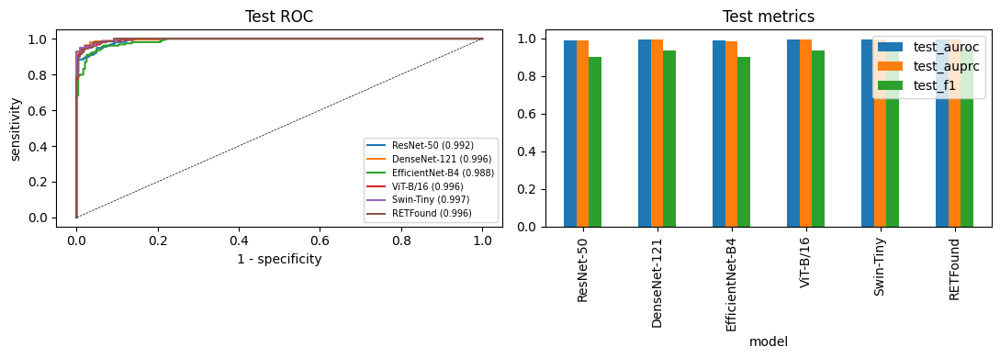

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name in MODEL_ZOO:
    pr = pd.read_csv(BASE_DIR[name] / 'predictions.csv').query('split == "test"')
    fpr, tpr, _ = roc_curve(pr.y, pr.prob)
    ax[0].plot(fpr, tpr, label=f'{name} ({base_res[name]["test"]["auroc"]:.3f})')
ax[0].plot([0, 1], [0, 1], 'k--', lw=0.5)
ax[0].set(title='Test ROC', xlabel='1 - specificity', ylabel='sensitivity')
ax[0].legend(fontsize=7)
baseline_table[['test_auroc', 'test_auprc', 'test_f1']].plot.bar(ax=ax[1], title='Test metrics')
plt.tight_layout()
plt.show()

*Interpretation, add after running:* which family did better, how large are the differences relative to the confidence intervals later in section 33?

## 30. Benchmark selection
Selected by **validation** AUROC (AUPRC breaks ties), never by test. The baseline files are then made read-only.

In [40]:
order = baseline_table.sort_values(['val_auroc', 'val_auprc'], ascending=False)
BENCHMARK = order.index[0]
REMAINING = [m for m in MODEL_ZOO if m != BENCHMARK]
if (DIRS['baseline'] / 'benchmark.json').exists():
    os.chmod(DIRS['baseline'] / 'benchmark.json', 0o644)
json.dump(dict(benchmark=BENCHMARK, criterion='validation AUROC, then AUPRC', val_auroc=float(order.val_auroc.iloc[0]),
               selected=time.strftime('%Y-%m-%d %H:%M:%S')), open(DIRS['baseline'] / 'benchmark.json', 'w'), indent=1)

for f in DIRS['baseline'].rglob('*'):
    if f.is_file():
        os.chmod(f, 0o444)
print('Benchmark model:', BENCHMARK, '| to improve:', REMAINING)

Benchmark model: Swin-Tiny | to improve: ['ResNet-50', 'DenseNet-121', 'EfficientNet-B4', 'ViT-B/16', 'RETFound']


## 31. Weaknesses of the remaining five
Diagnosis from the saved baseline runs: gap to the benchmark, overfitting (train vs validation), validation-to-test drop, sensitivity/specificity balance, calibration, and performance per source dataset.

In [41]:
rows = []
for name in REMAINING:
    r = base_res[name]
    rows.append(dict(model=name, gap_to_benchmark=base_res[BENCHMARK]['val']['auroc'] - r['val']['auroc'],
                     train_minus_val_auroc=r['train']['auroc'] - r['val']['auroc'],
                     val_minus_test_auroc=r['val']['auroc'] - r['test']['auroc'],
                     test_sensitivity=r['test']['sensitivity'], test_specificity=r['test']['specificity'],
                     test_ece=r['ece_test'], best_epoch=r['best_epoch'], epochs_run=r['epochs_run']))
diagnosis = pd.DataFrame(rows).set_index('model')
display(diagnosis.round(4))

per_ds = {}
for name in MODEL_ZOO:
    pr = pd.read_csv(BASE_DIR[name] / 'predictions.csv').query('split == "test"')
    per_ds[name] = pr.groupby('dataset').apply(lambda g: roc_auc_score(g.y, g.prob) if g.y.nunique() == 2 else np.nan)
print('Test AUROC per source dataset')
pd.DataFrame(per_ds).T.round(3)

,gap_to_benchmark,train_minus_val_auroc,val_minus_test_auroc,test_sensitivity,test_specificity,test_ece,best_epoch,epochs_run
model,,,,,,,,
ResNet-50,0.0092,0.0156,-0.0103,0.9935,0.8636,0.0370,4,8
DenseNet-121,0.0042,0.0128,-0.0092,0.9870,0.9215,0.0235,4,8
EfficientNet-B4,0.0054,0.0143,-0.0025,0.9740,0.8802,0.0362,6,10
ViT-B/16,0.0034,0.0123,-0.0081,0.9870,0.9256,0.0302,9,13
RETFound,0.0015,0.0105,-0.0064,0.9740,0.9587,0.0290,7,11


Test AUROC per source dataset


dataset,MMAC2023,PALM
ResNet-50,0.980,0.998
DenseNet-121,0.993,0.999
EfficientNet-B4,0.977,0.995
ViT-B/16,0.993,0.998
Swin-Tiny,0.994,0.999
RETFound,0.990,0.999


*Observations, add after running:* a large train-minus-val gap suggests regularization; low sensitivity or specificity suggests loss/threshold issues; a high ECE suggests calibration; a weak dataset suggests domain shift; a best epoch at the very end suggests the learning rate or schedule is too conservative.

## 32. Controlled improvement experiments
Rules: **one change at a time** relative to the original configuration, same split, seed, epochs and early stopping; decisions use validation metrics; results go to `improved/`, never into `baseline/`.
Architecture-level changes (multi-scale features, channel attention) are implemented for the CNNs only, where they make sense. Transformers use training-level changes, head changes and distillation.

In [42]:
class SEBlock(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(c, max(c // r, 4)), nn.ReLU(), nn.Linear(max(c // r, 4), c), nn.Sigmoid())

    def forward(self, x):
        w = self.fc(x.mean((2, 3)))
        return x * w[:, :, None, None]

class MultiScaleCNN(nn.Module):
    def __init__(self, timm_name, drop=0.0, se=False, pretrained=True):
        super().__init__()
        self.body = timm.create_model(timm_name, pretrained=pretrained, features_only=True, out_indices=(3, 4))
        chs = self.body.feature_info.channels()
        self.se = nn.ModuleList([SEBlock(c) if se else nn.Identity() for c in chs])
        self.drop = nn.Dropout(drop)
        self.fc = nn.Linear(sum(chs), 1)

    def forward(self, x):
        feats = self.body(x)
        pooled = [F.adaptive_avg_pool2d(s(f), 1).flatten(1) for s, f in zip(self.se, feats)]
        return self.fc(self.drop(torch.cat(pooled, 1)))

    def get_classifier(self):
        return self.fc

class MLPHead(nn.Module):
    def __init__(self, body, drop):
        super().__init__()
        self.body = body
        self.fc = nn.Sequential(nn.Linear(body.num_features, 256), nn.GELU(), nn.Dropout(drop), nn.Linear(256, 1))

    def forward(self, x):
        return self.fc(self.body(x))

    def get_classifier(self):
        return self.fc

def build_for(name, cfg):
    arch = cfg['arch']
    if arch == 'plain':
        return build_model(name, drop=cfg['drop'], weights=cfg['weights'])
    if arch == 'mlp_head':
        body = build_model(name, drop=0.0, weights=cfg['weights'])
        body.reset_classifier(0)
        return MLPHead(body, cfg['drop'])
    assert MODEL_ZOO[name]['kind'] == 'cnn', 'multi-scale / SE are implemented for CNNs only'
    return MultiScaleCNN(MODEL_ZOO[name]['timm'], cfg['drop'], se=arch == 'multiscale_se')

Experiment list: `name: (factor, change)`. Two experiments of the same factor are alternatives, not a combination. Alternative pretrained weights need a timm tag; list what exists below and add an entry yourself.

In [43]:
EXPERIMENTS = {
    'lr_low':        ('lr',      dict(lr=3e-5)),
    'lr_high':       ('lr',      dict(lr=3e-4)),
    'wd_high':       ('wd',      dict(weight_decay=0.05)),
    'dropout_0.3':   ('dropout', dict(drop=0.3)),
    'freeze_2ep':    ('freeze',  dict(freeze_epochs=2)),
    'head_lr_x10':   ('disc_lr', dict(head_lr_mult=10.0)),
    'pos_weight':    ('loss',    dict(loss='pos_weight')),
    'focal':         ('loss',    dict(loss='focal')),
    'mlp_head':      ('arch',    dict(arch='mlp_head', drop=0.3)),
    'multiscale':    ('arch',    dict(arch='multiscale')),
    'multiscale_se': ('arch',    dict(arch='multiscale_se')),
    'distill':       ('kd',      dict(kd_alpha=0.5)),
    # 'weights_alt': ('weights', dict(weights='<timm tag>')),
}

for name in REMAINING:
    print(name, '->', timm.list_pretrained(MODEL_ZOO[name]['timm'] + '*')[:8])

ResNet-50 -> ['resnet50.a1_in1k', 'resnet50.a1h_in1k', 'resnet50.a2_in1k', 'resnet50.a3_in1k', 'resnet50.am_in1k', 'resnet50.b1k_in1k', 'resnet50.b2k_in1k', 'resnet50.bt_in1k']
DenseNet-121 -> ['densenet121.ra_in1k', 'densenet121.tv_in1k']
EfficientNet-B4 -> ['efficientnet_b4.ra2_in1k']
ViT-B/16 -> ['vit_base_patch16_224.augreg2_in21k_ft_in1k', 'vit_base_patch16_224.augreg_in1k', 'vit_base_patch16_224.augreg_in21k', 'vit_base_patch16_224.augreg_in21k_ft_in1k', 'vit_base_patch16_224.dino', 'vit_base_patch16_224.mae', 'vit_base_patch16_224.orig_in21k', 'vit_base_patch16_224.orig_in21k_ft_in1k']
RETFound -> ['vit_large_patch16_224.augreg_in21k', 'vit_large_patch16_224.augreg_in21k_ft_in1k', 'vit_large_patch16_224.mae', 'vit_large_patch16_224.orig_in21k']


**[CHOOSE AFTER SECTION 31]** Pick experiments per model from the weakness table. Running every experiment on every model is possible but costs many GPU hours.

| Observation | Candidate experiments |
|---|---|
| large train-val gap | `wd_high`, `dropout_0.3`, `freeze_2ep` |
| slow or unstable convergence | `lr_low`, `lr_high`, `head_lr_x10` |
| sensitivity/specificity imbalance, class imbalance | `pos_weight`, `focal` |
| weak on small/diffuse findings (CNN) | `multiscale`, `multiscale_se` |
| still far from benchmark | `mlp_head`, `distill`, `weights_alt` |

In [53]:
PLAN = {m: ['head_lr_x10', 'pos_weight'] for m in REMAINING}   # default; better to pick from the cell 74 table if you have time
IMP_DIR = DIRS['improved']
assert PLAN, 'Fill PLAN with experiments chosen from the weakness analysis.'

teacher = None
if any(EXPERIMENTS[e][1].get('kd_alpha', 0) > 0 for exps in PLAN.values() for e in exps):
    teacher = build_model(BENCHMARK, pretrained=False).to(DEVICE).eval()
    teacher.load_state_dict(torch.load(BASE_DIR[BENCHMARK] / 'best.pth', map_location=DEVICE))

for name, exps in PLAN.items():
    for e in exps:
        out = IMP_DIR / name.replace('/', '_') / e
        if (out / 'results.json').exists():
            print('already done:', name, e)
            continue
        cfg = {**BASE_CFG, **EXPERIMENTS[e][1]}
        train_model(build_for(name, cfg), cfg, out, f'{name} | {e}', teacher=teacher if cfg['kd_alpha'] > 0 else None)

already done: ResNet-50 head_lr_x10
already done: ResNet-50 pos_weight
already done: DenseNet-121 head_lr_x10
already done: DenseNet-121 pos_weight
already done: EfficientNet-B4 head_lr_x10
[EfficientNet-B4 | pos_weight] start 2026-10-06 14:11:54


  0%|          | 0/112 [00:00<?, ?it/s]

epoch 01 | train 0.4688 | val 0.3750 | AUROC 0.9583 | AUPRC 0.9532 | 16s


  0%|          | 0/112 [00:00<?, ?it/s]

epoch 02 | train 0.2235 | val 0.3267 | AUROC 0.9705 | AUPRC 0.9682 | 16s


...

epoch 13 | train 0.0013 | val 0.3417 | AUROC 0.9901 | AUPRC 0.9886 | 70s


  0%|          | 0/112 [00:00<?, ?it/s]

epoch 14 | train 0.0047 | val 0.3658 | AUROC 0.9901 | AUPRC 0.9885 | 71s


  0%|          | 0/112 [00:00<?, ?it/s]

epoch 15 | train 0.0014 | val 0.3641 | AUROC 0.9900 | AUPRC 0.9884 | 90s
[RETFound | pos_weight] done in 20.8 min | best epoch 13


In [51]:
# ============================================================
# Resume final evaluation for EfficientNet-B4 | head_lr_x10
# No retraining — loads existing best.pth
# ============================================================

name = 'EfficientNet-B4'
e = 'head_lr_x10'

out = IMP_DIR / name.replace('/', '_') / e

assert (out / 'best.pth').exists(), f"Missing checkpoint: {out / 'best.pth'}"

# Recreate the exact model configuration
cfg = {**BASE_CFG, **EXPERIMENTS[e][1]}

print(f"Loading checkpoint: {out / 'best.pth'}")

# Build model
model = build_for(name, cfg).to(DEVICE)

# Load the already-trained best model
model.load_state_dict(
    torch.load(out / 'best.pth', map_location=DEVICE)
)

model.eval()

# ------------------------------------------------------------
# 1. Select threshold from VALIDATION set
# ------------------------------------------------------------

yv, pv, _ = predict(model, val_loader)

fpr, tpr, thr = roc_curve(yv, pv)
threshold = float(thr[np.argmax(tpr - fpr)])

print(f"Validation threshold: {threshold:.6f}")

# ------------------------------------------------------------
# 2. Evaluate train / validation / test
# ------------------------------------------------------------

res = dict(
    model=f'{name} | {e}',
    cfg=cfg,
    params_M=sum(p.numel() for p in model.parameters()) / 1e6,
    threshold=threshold
)

preds = []

for split, loader, df in [
    ('train', train_eval_loader, train_df),
    ('val', val_loader, val_df),
    ('test', test_loader, test_df)
]:

    print(f"\nEvaluating {split}...")

    y, p, loss = predict(model, loader)

    res[split] = classification_metrics(
        y, p, threshold
    )

    if split == 'test':
        res['ece_test'] = ece_score(y, p)

    preds.append(
        pd.DataFrame({
            'uid': df.uid.values,
            'dataset': df.dataset.values,
            'split': split,
            'y': y,
            'prob': p
        })
    )

    print(
        f"{split}: "
        f"AUROC={res[split]['auroc']:.4f} | "
        f"AUPRC={res[split]['auprc']:.4f} | "
        f"F1={res[split]['f1']:.4f}"
    )

# ------------------------------------------------------------
# 3. Save the missing result files
# ------------------------------------------------------------

# Keep existing history.csv if it was created
if not (out / 'history.csv').exists():
    print("Warning: history.csv does not exist.")

pd.concat(preds).to_csv(
    out / 'predictions.csv',
    index=False
)

json.dump(
    res,
    open(out / 'results.json', 'w'),
    indent=1,
    default=float
)

print("\n============================================")
print("EfficientNet-B4 | head_lr_x10 COMPLETE")
print("============================================")
print(f"Saved: {out / 'predictions.csv'}")
print(f"Saved: {out / 'results.json'}")
print(f"Threshold: {threshold:.6f}")

Loading checkpoint: /kaggle/working/pm_research/improved/EfficientNet-B4/head_lr_x10/best.pth
Validation threshold: 0.091237

Evaluating train...
train: AUROC=1.0000 | AUPRC=1.0000 | F1=0.9912

Evaluating val...
val: AUROC=0.9849 | AUPRC=0.9825 | F1=0.9360

Evaluating test...
test: AUROC=0.9899 | AUPRC=0.9830 | F1=0.9371

EfficientNet-B4 | head_lr_x10 COMPLETE
Saved: /kaggle/working/pm_research/improved/EfficientNet-B4/head_lr_x10/predictions.csv
Saved: /kaggle/working/pm_research/improved/EfficientNet-B4/head_lr_x10/results.json
Threshold: 0.091237


## 34. Ablation summary
Change in validation AUROC/AUPRC against the model's own original run. Single-seed differences smaller than the seed-to-seed variation should not be claimed as improvements; rerun the top candidates with another `seed` in the config if a difference is small.

,model,experiment,factor,val_auroc,val_auprc,delta_val_auroc,delta_val_auprc,best_epoch,minutes
3,DenseNet-121,pos_weight,loss,0.9908,0.9888,0.0041,0.0039,4.0,4.5
2,DenseNet-121,head_lr_x10,disc_lr,0.9876,0.9864,0.0009,0.0016,2.0,2.7
4,EfficientNet-B4,head_lr_x10,disc_lr,0.9849,0.9825,-0.0006,-0.0007,NaN,NaN
5,EfficientNet-B4,pos_weight,loss,0.9847,0.9829,-0.0008,-0.0003,9.0,7.0
9,RETFound,pos_weight,loss,0.9901,0.9886,0.0007,-0.0012,13.0,20.8
8,RETFound,head_lr_x10,disc_lr,0.9895,0.9880,0.0001,-0.0019,1.0,6.6
0,ResNet-50,head_lr_x10,disc_lr,0.9882,0.9873,0.0064,0.0065,10.0,5.5
1,ResNet-50,pos_weight,loss,0.9860,0.9850,0.0043,0.0042,5.0,6.9
6,ViT-B/16,head_lr_x10,disc_lr,0.9896,0.9878,0.0020,0.0015,3.0,4.9
7,ViT-B/16,pos_weight,loss,0.9855,0.9835,-0.0021,-0.0028,2.0,3.1


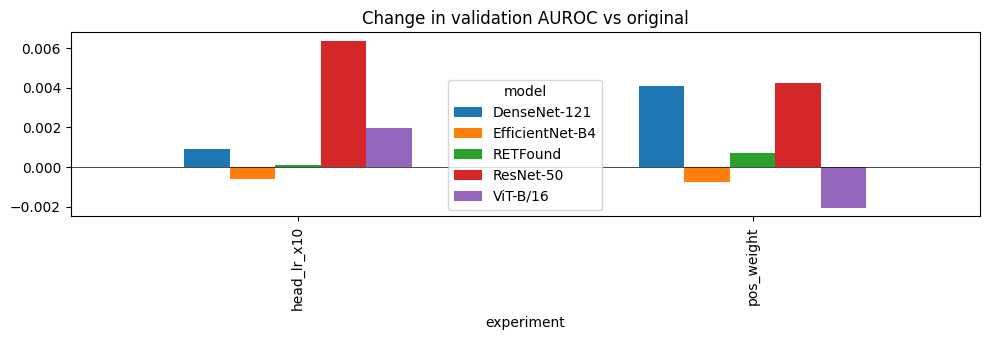

In [61]:
rows = []

for name, exps in PLAN.items():
    for e in exps:

        result_path = IMP_DIR / name.replace('/', '_') / e / 'results.json'

        if not result_path.exists():
            print("MISSING:", result_path)
            continue

        r = read_json(result_path)

        rows.append(dict(
            model=name,
            experiment=e,
            factor=EXPERIMENTS[e][0],

            val_auroc=r['val']['auroc'],
            val_auprc=r['val']['auprc'],

            delta_val_auroc=(
                r['val']['auroc'] -
                base_res[name]['val']['auroc']
            ),

            delta_val_auprc=(
                r['val']['auprc'] -
                base_res[name]['val']['auprc']
            ),

            # Safely handle missing fields
            best_epoch=r.get('best_epoch', np.nan),
            minutes=round(r.get('minutes', np.nan), 1)
        ))

ablation = pd.DataFrame(rows)

ablation.to_csv(
    DIRS['results'] / 'ablation_table.csv',
    index=False
)

display(
    ablation
    .sort_values(
        ['model', 'delta_val_auroc'],
        ascending=[True, False]
    )
    .round(4)
)

# Plot
ablation.pivot(
    index='experiment',
    columns='model',
    values='delta_val_auroc'
).plot.bar(
    figsize=(10, 3.5),
    title='Change in validation AUROC vs original'
)

plt.axhline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

Accept an experiment only if it improves validation AUROC by at least `ACCEPT_MARGIN`. Per factor the best one is kept, the accepted changes are combined into one configuration, and that combined model is trained once. The final "improved" model of each architecture is whichever of original, single changes or combination has the best **validation** AUROC. If nothing helps, the improved model is the original, and that is reported as is.

In [63]:
ACCEPT_MARGIN = 0.005
improved = {}

for name in PLAN:
    ok = ablation[(ablation.model == name) & (ablation.delta_val_auroc >= ACCEPT_MARGIN)]
    chosen = ok.sort_values('delta_val_auroc', ascending=False).groupby('factor').head(1).experiment.tolist()
    candidates = {'original': (BASE_DIR[name], BASE_CFG)}
    for e in ablation[ablation.model == name].experiment:
        candidates[e] = (IMP_DIR / name.replace('/', '_') / e, {**BASE_CFG, **EXPERIMENTS[e][1]})
    if len(chosen) > 1:
        cfg = dict(BASE_CFG)
        for e in chosen:
            cfg.update(EXPERIMENTS[e][1])
        out = IMP_DIR / name.replace('/', '_') / 'combined'
        if not (out / 'results.json').exists():
            train_model(build_for(name, cfg), cfg, out, f'{name} | combined', teacher=teacher if cfg['kd_alpha'] > 0 else None)
        candidates['combined'] = (out, cfg)
    best = max(candidates, key=lambda k: read_json(candidates[k][0] / 'results.json')['val']['auroc'])
    improved[name] = dict(source=best, dir=candidates[best][0], cfg=candidates[best][1], accepted=chosen)
    print(f'{name}: accepted {chosen} -> final improved = {best}')

ResNet-50: accepted ['head_lr_x10'] -> final improved = head_lr_x10
DenseNet-121: accepted [] -> final improved = pos_weight
EfficientNet-B4: accepted [] -> final improved = original
ViT-B/16: accepted [] -> final improved = head_lr_x10
RETFound: accepted [] -> final improved = pos_weight


## 33. Original vs Improved vs Benchmark
Test AUROC with a paired bootstrap (1000 resamples of test images) for the differences. Images are resampled individually, so patient clustering is ignored; treat intervals as approximate.

In [64]:
def boot_auc_diff(df_a, df_b, n=1000):
    d = df_a.merge(df_b, on=['uid', 'y'], suffixes=('_a', '_b'))
    rng = np.random.default_rng(SEED)
    diffs = []
    for _ in range(n):
        i = rng.integers(0, len(d), len(d))
        y = d.y.values[i]
        if y.min() == y.max():
            continue
        diffs.append(roc_auc_score(y, d.prob_a.values[i]) - roc_auc_score(y, d.prob_b.values[i]))
    return float(np.mean(diffs)), *np.percentile(diffs, [2.5, 97.5])

def test_preds(folder):
    return pd.read_csv(folder / 'predictions.csv').query('split == "test"')

bench_pred = test_preds(BASE_DIR[BENCHMARK])
rows = []
for name, info in improved.items():
    orig_pred, imp_pred = test_preds(BASE_DIR[name]), test_preds(info['dir'])
    vs_orig = boot_auc_diff(imp_pred, orig_pred)
    vs_bench = boot_auc_diff(imp_pred, bench_pred)
    verdict = 'surpasses benchmark' if vs_bench[1] > 0 else ('below benchmark' if vs_bench[2] < 0 else 'matches benchmark (CI includes 0)')
    imp_res = read_json(info['dir'] / 'results.json')
    rows.append(dict(model=name, improved_from=info['source'], original_auroc=base_res[name]['test']['auroc'],
                     improved_auroc=imp_res['test']['auroc'], benchmark_auroc=base_res[BENCHMARK]['test']['auroc'],
                     improved_auprc=imp_res['test']['auprc'], improved_f1=imp_res['test']['f1'],
                     diff_vs_original=f'{vs_orig[0]:+.3f} [{vs_orig[1]:+.3f}, {vs_orig[2]:+.3f}]',
                     diff_vs_benchmark=f'{vs_bench[0]:+.3f} [{vs_bench[1]:+.3f}, {vs_bench[2]:+.3f}]', verdict=verdict))
comparison = pd.DataFrame(rows).set_index('model')
comparison.to_csv(DIRS['results'] / 'original_vs_improved_vs_benchmark.csv')
comparison.round(4)

,improved_from,original_auroc,improved_auroc,benchmark_auroc,improved_auprc,improved_f1,diff_vs_original,diff_vs_benchmark,verdict
model,,,,,,,,,
ResNet-50,head_lr_x10,0.9921,0.9933,0.9968,0.9909,0.9397,"+0.001 [-0.003, +0.005]","-0.004 [-0.008, -0.000]",below benchmark
DenseNet-121,pos_weight,0.9959,0.9953,0.9968,0.9929,0.9412,"-0.001 [-0.004, +0.003]","-0.002 [-0.005, +0.001]",matches benchmark (CI includes 0)
EfficientNet-B4,original,0.9880,0.9880,0.9968,0.9827,0.9009,"+0.000 [+0.000, +0.000]","-0.009 [-0.015, -0.004]",below benchmark
ViT-B/16,head_lr_x10,0.9957,0.9928,0.9968,0.9884,0.9350,"-0.003 [-0.006, -0.000]","-0.004 [-0.008, -0.001]",below benchmark
RETFound,pos_weight,0.9958,0.9964,0.9968,0.9945,0.9521,"+0.001 [-0.001, +0.002]","-0.000 [-0.003, +0.002]",matches benchmark (CI includes 0)


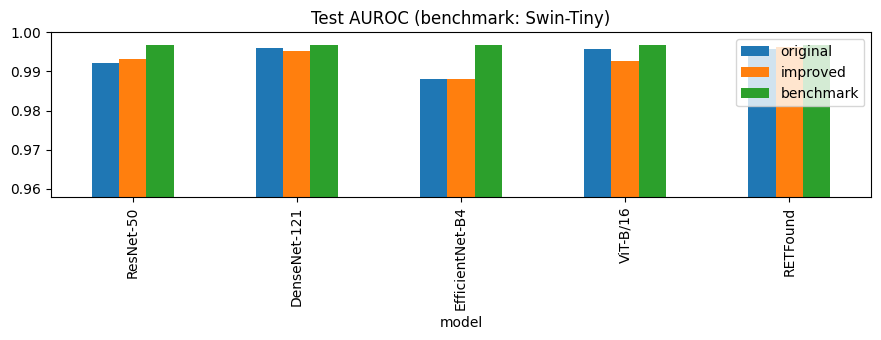

In [65]:
plot_df = pd.DataFrame({'original': comparison.original_auroc, 'improved': comparison.improved_auroc, 'benchmark': comparison.benchmark_auroc})
plot_df.plot.bar(figsize=(9, 3.5), title=f'Test AUROC (benchmark: {BENCHMARK})')
plt.ylim(plot_df.values.min() - 0.03, min(1.0, plot_df.values.max() + 0.02))
plt.tight_layout()
plt.show()

*Interpretation, add after running:* which models improved, which closed the gap, whether any surpassed the benchmark, and whether a change helped one metric while hurting another.

## 35. Final model
Best validation AUROC among the benchmark and the improved models. Set `FINAL_OVERRIDE` only with a written reason.

In [66]:
FINAL_OVERRIDE = None
pool = {BENCHMARK: dict(dir=BASE_DIR[BENCHMARK], cfg=BASE_CFG, source='baseline')}
pool.update({n: dict(dir=i['dir'], cfg=i['cfg'], source=i['source']) for n, i in improved.items()})
FINAL_NAME = FINAL_OVERRIDE or max(pool, key=lambda n: read_json(pool[n]['dir'] / 'results.json')['val']['auroc'])
FINAL = pool[FINAL_NAME]
print('Final model:', FINAL_NAME, '| from:', FINAL['source'], '| checkpoint:', FINAL['dir'] / 'best.pth')

Final model: Swin-Tiny | from: baseline | checkpoint: /kaggle/working/pm_research/baseline/Swin-Tiny/best.pth


## 36-37. Multi-task Pathological Myopia analysis
The final model's backbone is initialised from its classification checkpoint (stage 1) and fine-tuned with several heads (stage 2). A head is built **only if enough training images carry that annotation**.

Architecture notes: the PM, severity and fovea heads sit on the pooled backbone features. Segmentation uses a plain progressive-upsampling decoder (no skip connections) on the last feature map, so masks are coarse; a U-Net-style decoder would be the next step if disc/atrophy Dice is limiting. Quantification (areas, densities, distances) is computed from the predicted masks, not learned.

In [67]:
MIN_ANN = 30           # minimum annotated training images to switch a task on
train_all = meta_prep[meta_prep.split == 'train']
n_ann = {'severity': int(train_all.severity.notna().sum()), 'fovea': int(train_all.fovea_x_n.notna().sum()),
         **{t: int(train_all[f'prep_{t}'].notna().sum()) for t in SEG_TASKS}}
ACTIVE_SEG = [t for t in SEG_TASKS if n_ann[t] >= MIN_ANN]
USE_SEV = n_ann['severity'] >= MIN_ANN
USE_FOV = n_ann['fovea'] >= MIN_ANN
N_SEG = max(len(ACTIVE_SEG), 1)
FINAL_KIND = MODEL_ZOO[FINAL_NAME]['kind']
print('annotated training images:', n_ann)
print('active heads -> segmentation:', ACTIVE_SEG, '| severity:', USE_SEV, '| fovea:', USE_FOV)

annotated training images: {'severity': 974, 'fovea': 830, 'disc': 34, 'atrophy': 0, 'lesion_lc': 54, 'lesion_cnv': 28, 'lesion_fs': 42, 'tessellation': 0}
active heads -> segmentation: ['disc', 'lesion_lc', 'lesion_fs'] | severity: True | fovea: True


## 16b. Multi-task data
Each item carries its targets plus 0/1 flags saying which targets exist. Augmentation moves image, masks and fovea point together.

In [68]:
mt_train_tf = A.Compose([A.HorizontalFlip(p=0.5),
                         A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.5),
                         A.RandomBrightnessContrast(0.1, 0.1, p=0.5),
                         A.Normalize(MEAN, STD), ToTensorV2()],
                        keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))
mt_eval_tf = A.Compose([A.Normalize(MEAN, STD), ToTensorV2()],
                       keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

class MultiTaskDataset(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True)
        self.tf = tf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        masks, has_mask = [], []
        for t in ACTIVE_SEG:
            p = r[f'prep_{t}']
            if isinstance(p, str):
                masks.append((cv2.imread(p, 0) > 127).astype(np.uint8))
                has_mask.append(1.0)
            else:
                masks.append(np.zeros((IMG_SIZE, IMG_SIZE), np.uint8))
                has_mask.append(0.0)
        if not masks:
            masks, has_mask = [np.zeros((IMG_SIZE, IMG_SIZE), np.uint8)], [0.0]

        has_fovea = USE_FOV and pd.notna(r.fovea_x_n)
        points = [(r.fovea_x_n * IMG_SIZE, r.fovea_y_n * IMG_SIZE)] if has_fovea else []
        out = self.tf(image=read_rgb(r.prep_image), masks=masks, keypoints=points)

        fovea = torch.zeros(2)
        if has_fovea and len(out['keypoints']):
            fovea = (torch.tensor([float(out['keypoints'][0][0]), float(out['keypoints'][0][1])]) / IMG_SIZE).clamp(0, 1)
        else:
            has_fovea = False

        return dict(image=out['image'], uid=r.uid,
                    pm=torch.tensor(float(r.pm_label) if pd.notna(r.pm_label) else 0.0),
                    has_pm=torch.tensor(float(pd.notna(r.pm_label))),
                    sev=torch.tensor(int(r.severity) if USE_SEV and pd.notna(r.severity) else -1, dtype=torch.long),
                    masks=torch.stack([torch.as_tensor(m) for m in out['masks']]).float(),
                    has_mask=torch.tensor(has_mask), fovea=fovea, has_fovea=torch.tensor(float(has_fovea)))

MT_BATCH = 16
mt_args = dict(batch_size=MT_BATCH, num_workers=NUM_WORKERS, pin_memory=True, worker_init_fn=seed_worker)
mt_frames = {s: meta_prep[meta_prep.split == s].reset_index(drop=True) for s in ['train', 'val', 'test']}
mt_train = DataLoader(MultiTaskDataset(mt_frames['train'], mt_train_tf), shuffle=True, drop_last=True, generator=g, **mt_args)
mt_val = DataLoader(MultiTaskDataset(mt_frames['val'], mt_eval_tf), shuffle=False, **mt_args)
mt_test = DataLoader(MultiTaskDataset(mt_frames['test'], mt_eval_tf), shuffle=False, **mt_args)
fundus_path = dict(zip(meta_prep.uid, meta_prep.prep_fundus))
print({k: len(v) for k, v in mt_frames.items()})

{'train': 2159, 'val': 474, 'test': 473}


## 37b. Multi-task model
`to_map` turns any backbone output (CNN map, ViT tokens, Swin NHWC) into a `(B, C, h, w)` map.

In [69]:
def to_map(f, kind):
    if kind == 'cnn':
        return f
    if kind == 'swin':
        return f.permute(0, 3, 1, 2)
    f = f[:, 1:]                                   # drop the class token
    side = int(f.shape[1] ** 0.5)
    return f.transpose(1, 2).reshape(f.shape[0], -1, side, side)

def up_block(c_in, c_out):
    return nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                         nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU())

class MultiTaskNet(nn.Module):
    def __init__(self, name, weights=None):
        super().__init__()
        self.kind = MODEL_ZOO[name]['kind']
        self.backbone = build_model(name, weights=weights)
        self.backbone.reset_classifier(0)
        d = self.backbone.num_features
        self.norm = nn.LayerNorm(d)
        self.pm = nn.Linear(d, 1)
        self.sev = nn.Linear(d, len(SEVERITY_NAMES))
        self.fov = nn.Linear(d, 2)
        self.dec = nn.Sequential(up_block(d, 256), up_block(256, 128), up_block(128, 64), nn.Conv2d(64, N_SEG, 1))

    def forward(self, x):
        f = to_map(self.backbone.forward_features(x), self.kind)
        v = self.norm(f.mean((2, 3)))
        seg = F.interpolate(self.dec(f), size=x.shape[-2:], mode='bilinear', align_corners=False)
        return dict(pm=self.pm(v).squeeze(1), sev=self.sev(v), fov=torch.sigmoid(self.fov(v)), seg=seg)

def load_backbone(model, ckpt_path):
    state = torch.load(ckpt_path, map_location='cpu')
    state = {k.replace('body.', '', 1): v for k, v in state.items()}
    own = model.backbone.state_dict()
    state = {k: v for k, v in state.items() if k in own and own[k].shape == v.shape}
    model.backbone.load_state_dict(state, strict=False)
    print(f'initialised {len(state)} of {len(own)} backbone tensors from the classification checkpoint')

## 38. Losses
- PM: binary cross-entropy. Severity: cross-entropy. Segmentation: BCE + soft Dice per mask. Fovea: L1 on normalised coordinates.
- Every loss is multiplied by its availability flag, so an image without that annotation adds nothing.
- The task weights are fixed starting values, not tuned. Change them only by looking at validation results.

In [70]:
MT_CFG = dict(seed=SEED, epochs=15, lr=1e-4, head_lr_mult=10.0, weight_decay=1e-2, patience=4, grad_clip=1.0,
              loss_w=dict(pm=1.0, sev=1.0, seg=1.0, fov=10.0))

def mt_loss(out, b):
    parts = {}
    has_pm = b['has_pm']
    parts['pm'] = (F.binary_cross_entropy_with_logits(out['pm'], b['pm'], reduction='none') * has_pm).sum() / has_pm.sum().clamp(min=1)
    if USE_SEV:
        valid = (b['sev'] >= 0).float()
        ce = F.cross_entropy(out['sev'], b['sev'].clamp(min=0), reduction='none')
        parts['sev'] = (ce * valid).sum() / valid.sum().clamp(min=1)
    if ACTIVE_SEG:
        m, logit = b['masks'], out['seg']
        bce = F.binary_cross_entropy_with_logits(logit, m, reduction='none').mean((2, 3))
        p = torch.sigmoid(logit)
        dice = 1 - (2 * (p * m).sum((2, 3)) + 1) / (p.sum((2, 3)) + m.sum((2, 3)) + 1)
        parts['seg'] = ((bce + dice) * b['has_mask']).sum() / b['has_mask'].sum().clamp(min=1)
    if USE_FOV:
        l1 = (out['fov'] - b['fovea']).abs().mean(1)
        parts['fov'] = (l1 * b['has_fovea']).sum() / b['has_fovea'].sum().clamp(min=1)
    total = sum(MT_CFG['loss_w'][k] * v for k, v in parts.items())
    return total, parts

## 22b. Multi-task training
Same logic as the baseline loop. Best epoch = lowest validation total loss. Checkpoint, history and timings are saved in `multitask/`.

In [71]:
def run_mt_epoch(model, loader, optimizer=None, scaler=None):
    train = optimizer is not None
    model.train(train)
    sums, n = {}, 0
    for b in tqdm(loader, leave=False):
        x = b['image'].to(DEVICE, non_blocking=True)
        b = {k: v.to(DEVICE) for k, v in b.items() if k not in ('image', 'uid')}
        with torch.set_grad_enabled(train):
            with torch.autocast(DEVICE.type, enabled=USE_AMP):
                out = model(x)
            loss, parts = mt_loss({k: v.float() for k, v in out.items()}, b)
        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), MT_CFG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
        n += 1
        sums['total'] = sums.get('total', 0) + loss.item()
        for k, v in parts.items():
            sums[k] = sums.get(k, 0) + v.item()
    return {k: v / n for k, v in sums.items()}

def train_mt(model, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    cfg = MT_CFG
    set_seed(cfg['seed'])
    model = model.to(DEVICE)
    body = list(model.backbone.parameters())
    head = [p for n_, m_ in model.named_children() if n_ != 'backbone' for p in m_.parameters()]
    optimizer = torch.optim.AdamW([{'params': body, 'lr': cfg['lr']}, {'params': head, 'lr': cfg['lr'] * cfg['head_lr_mult']}],
                                  weight_decay=cfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    history, best, best_epoch, wait = [], 1e9, 0, 0
    start = time.time()
    print('multi-task training start', time.strftime('%Y-%m-%d %H:%M:%S'))
    for epoch in range(cfg['epochs']):
        t0 = time.time()
        lr_now = optimizer.param_groups[0]['lr']
        tr = run_mt_epoch(model, mt_train, optimizer, scaler)
        va = run_mt_epoch(model, mt_val)
        scheduler.step()
        history.append(dict(epoch=epoch + 1, lr=lr_now, **{f'train_{k}': v for k, v in tr.items()},
                            **{f'val_{k}': v for k, v in va.items()}, epoch_sec=time.time() - t0))
        print(f'epoch {epoch + 1:02d} | train {tr["total"]:.4f} | val {va["total"]:.4f} | ' + ' '.join(f'{k} {v:.3f}' for k, v in va.items() if k != 'total') + f' | {time.time() - t0:.0f}s')
        if va['total'] < best - 1e-4:
            best, best_epoch, wait = va['total'], epoch + 1, 0
            torch.save(model.state_dict(), out_dir / 'best.pth')
        else:
            wait += 1
            if wait >= cfg['patience']:
                print('early stopping')
                break
    pd.DataFrame(history).to_csv(out_dir / 'history.csv', index=False)
    info = dict(final_model=FINAL_NAME, cfg=cfg, best_epoch=best_epoch, active_seg=ACTIVE_SEG, use_sev=USE_SEV, use_fovea=USE_FOV,
                start=time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start)), end=time.strftime('%Y-%m-%d %H:%M:%S'),
                minutes=(time.time() - start) / 60)
    json.dump(info, open(out_dir / 'info.json', 'w'), indent=1, default=float)
    model.load_state_dict(torch.load(out_dir / 'best.pth', map_location=DEVICE))
    return model

initialised 171 of 171 backbone tensors from the classification checkpoint
multi-task training start 2026-10-06 15:14:51


  0%|          | 0/134 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

epoch 01 | train 2.3816 | val 0.7746 | pm 0.131 sev 0.266 seg 0.087 fov 0.029 | 19s


  0%|          | 0/134 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1cfdc93f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


epoch 14 | train 0.7036 | val 0.6157 | pm 0.163 sev 0.245 seg 0.075 fov 0.013 | 40s


  0%|          | 0/134 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

epoch 15 | train 0.6976 | val 0.6144 | pm 0.160 sev 0.247 seg 0.075 fov 0.013 | 40s


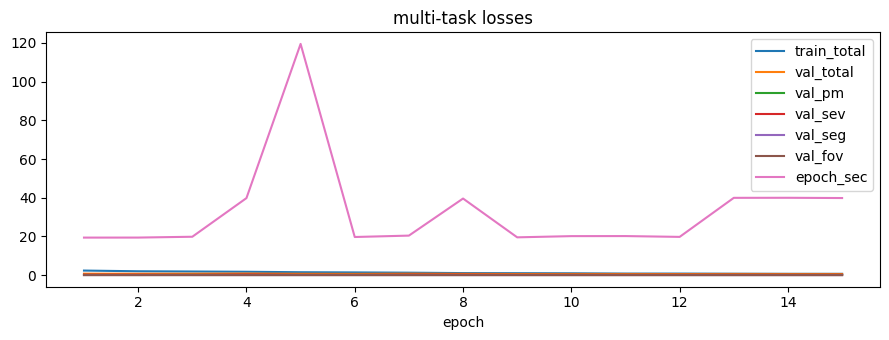

In [72]:
MT_DIR = DIRS['multitask']
mt_model = MultiTaskNet(FINAL_NAME, weights=FINAL['cfg'].get('weights'))
if (MT_DIR / 'best.pth').exists():
    mt_model.load_state_dict(torch.load(MT_DIR / 'best.pth', map_location='cpu'))
    mt_model = mt_model.to(DEVICE)
    print('loaded existing multi-task checkpoint')
else:
    load_backbone(mt_model, FINAL['dir'] / 'best.pth')
    mt_model = train_mt(mt_model, MT_DIR)

hist = pd.read_csv(MT_DIR / 'history.csv')
hist.filter(regex='epoch|val_|train_total').set_index('epoch').plot(figsize=(9, 3.5), title='multi-task losses')
plt.tight_layout()
plt.show()

## 39. Inference and quantification
For every image, the predicted masks give lesion area, share of the fundus, density inside two regions, mean distance to disc and fovea, and quadrant shares. The same numbers are computed from ground-truth masks where those exist, so the quantification itself can be validated.

Settings to confirm against the protocol you follow: the macular circle radius and the peripapillary ring radius, both in **optic-disc diameters (DD)**. Pixel areas are not converted to mm² because pixel spacing is not known. For the tessellation channel, density = fundus tessellation density (FTD).

In [73]:
MAC_R = 3.0        # macular region radius around the fovea, in DD (assumption, confirm)
PERI_R = 1.5       # peripapillary region radius around the disc centre, in DD (assumption, confirm)
SUCCESS_PX = (10, 20, 40)
YY, XX = np.mgrid[:IMG_SIZE, :IMG_SIZE]

def measure(m, fundus, disc_mask, fov):
    out = {'area_px': int(m.sum()), 'pct_fundus': 100 * m.sum() / max(fundus.sum(), 1)}
    if disc_mask is None or disc_mask.sum() == 0 or fov is None:
        return out
    cy, cx = np.argwhere(disc_mask).mean(0)
    dd = np.sqrt(4 * disc_mask.sum() / np.pi)
    d_disc = np.hypot(XX - cx, YY - cy) / dd
    d_fov = np.hypot(XX - fov[0], YY - fov[1]) / dd
    regions = {'macular': (d_fov <= MAC_R) & fundus, 'peripapillary': (d_disc <= PERI_R) & ~disc_mask & fundus}
    for rname, reg in regions.items():
        out[f'{rname}_area_px'] = int((m & reg).sum())
        out[f'{rname}_density'] = (m & reg).sum() / max(reg.sum(), 1)
    out['mean_dist_disc_dd'] = d_disc[m].mean() if m.any() else np.nan
    out['mean_dist_fovea_dd'] = d_fov[m].mean() if m.any() else np.nan
    quadrant = ((np.arctan2(YY - cy, XX - cx) + np.pi) // (np.pi / 2)).astype(int) % 4
    for q in range(4):
        out[f'quadrant{q}_share'] = (m & (quadrant == q)).sum() / max(m.sum(), 1)
    return out

@torch.no_grad()
def infer_mt(model, loader, keep=8):
    model.eval()
    rows, shown = [], []
    for b in tqdm(loader, leave=False):
        with torch.autocast(DEVICE.type, enabled=USE_AMP):
            out = model(b['image'].to(DEVICE))
        pm = torch.sigmoid(out['pm'].float()).cpu().numpy()
        sev = out['sev'].float().cpu().numpy()
        fov = out['fov'].float().cpu().numpy() * IMG_SIZE
        pred = (torch.sigmoid(out['seg'].float()) > 0.5).cpu().numpy()
        gt = b['masks'].numpy() > 0.5
        for j, uid in enumerate(b['uid']):
            row = dict(uid=uid, pm_prob=float(pm[j]), sev_pred=int(sev[j].argmax()), fovea_x_pred=float(fov[j, 0]), fovea_y_pred=float(fov[j, 1]))
            gt_fov = b['fovea'][j].numpy() * IMG_SIZE if USE_FOV and b['has_fovea'][j] > 0 else None
            if gt_fov is not None:
                row['fovea_err_px'] = float(np.hypot(*(fov[j] - gt_fov)))
            fundus = cv2.imread(fundus_path[uid], 0) > 127
            has_disc = 'disc' in ACTIVE_SEG
            k_disc = ACTIVE_SEG.index('disc') if has_disc else None
            pred_disc = pred[j, k_disc] if has_disc else None
            gt_disc = gt[j, k_disc] if has_disc and b['has_mask'][j, k_disc] > 0 else None
            for k, t in enumerate(ACTIVE_SEG):
                has = b['has_mask'][j, k] > 0
                if has:
                    inter, union = (pred[j, k] & gt[j, k]).sum(), (pred[j, k] | gt[j, k]).sum()
                    row[f'dice_{t}'] = (2 * inter + 1) / (pred[j, k].sum() + gt[j, k].sum() + 1)
                    row[f'iou_{t}'] = (inter + 1) / (union + 1)
                if t != 'disc':
                    row.update({f'{t}_pred_{key}': v for key, v in measure(pred[j, k], fundus, pred_disc, fov[j] if USE_FOV else None).items()})
                    if has:
                        row.update({f'{t}_gt_{key}': v for key, v in measure(gt[j, k], fundus, gt_disc, gt_fov).items()})
            rows.append(row)
            if len(shown) < keep:
                shown.append(dict(uid=uid, pred=pred[j], gt=gt[j], has=b['has_mask'][j].numpy(), fov_pred=fov[j], fov_gt=gt_fov))
    return pd.DataFrame(rows), shown

val_out, _ = infer_mt(mt_model, mt_val)
test_out, shown = infer_mt(mt_model, mt_test)
info = meta_prep.set_index('uid')[['dataset', 'pm_label', 'severity']]
val_out, test_out = val_out.join(info, on='uid'), test_out.join(info, on='uid')
test_out.to_csv(MT_DIR / 'test_predictions.csv', index=False)
val_out.to_csv(MT_DIR / 'val_predictions.csv', index=False)
test_out.shape

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

(473, 43)

## 39b. Evaluation per task
- PM: AUROC/AUPRC and threshold metrics (threshold from validation).
- Severity: macro-F1, quadratic weighted kappa (rewards near misses), accuracy.
- Segmentation: Dice and IoU per image, averaged over images that have that mask (smoothing of 1 pixel).
- Fovea: Euclidean error in pixels of the `IMG_SIZE` image and success rate within thresholds.

In [74]:
mt_metrics = {}

vp, tp_ = val_out.dropna(subset=['pm_label']), test_out.dropna(subset=['pm_label'])
fpr, tpr, thr = roc_curve(vp.pm_label, vp.pm_prob)
mt_thr = float(thr[np.argmax(tpr - fpr)])
mt_metrics['pm'] = classification_metrics(tp_.pm_label.values, tp_.pm_prob.values, mt_thr)
mt_metrics['pm']['ece'] = ece_score(tp_.pm_label.values, tp_.pm_prob.values)

if USE_SEV:
    s = test_out.dropna(subset=['severity'])
    mt_metrics['severity'] = dict(macro_f1=f1_score(s.severity, s.sev_pred, average='macro'), qwk=cohen_kappa_score(s.severity, s.sev_pred, weights='quadratic'),
                                  accuracy=float((s.severity == s.sev_pred).mean()), n=len(s))

for t in ACTIVE_SEG:
    mt_metrics[f'seg_{t}'] = dict(dice=float(test_out[f'dice_{t}'].mean()), iou=float(test_out[f'iou_{t}'].mean()), n=int(test_out[f'dice_{t}'].notna().sum()))

if USE_FOV and 'fovea_err_px' in test_out:
    e = test_out.fovea_err_px.dropna()
    mt_metrics['fovea'] = dict(mean_err_px=float(e.mean()), median_err_px=float(e.median()), n=len(e),
                               **{f'success_{t}px': float((e <= t).mean()) for t in SUCCESS_PX})

for t in [t for t in ACTIVE_SEG if t != 'disc']:
    both = test_out.dropna(subset=[f'{t}_gt_pct_fundus'])
    if len(both) > 2:
        mt_metrics[f'quant_{t}'] = dict(pct_area_mae=float((both[f'{t}_pred_pct_fundus'] - both[f'{t}_gt_pct_fundus']).abs().mean()),
                                        pct_area_corr=float(np.corrcoef(both[f'{t}_pred_pct_fundus'], both[f'{t}_gt_pct_fundus'])[0, 1]), n=len(both))

single = read_json(FINAL['dir'] / 'results.json')
mt_metrics['pm_single_task_reference'] = single['test']
json.dump(mt_metrics, open(DIRS['results'] / 'multitask_metrics.json', 'w'), indent=1, default=float)
pd.json_normalize(mt_metrics, sep='.').T.rename(columns={0: 'value'}).round(4)

,value
pm.auroc,0.9962
pm.auprc,0.9942
pm.f1,0.9474
pm.precision,0.9053
pm.recall,0.9935
pm.sensitivity,0.9935
pm.specificity,0.9339
pm.ece,0.0362
severity.macro_f1,0.7250
severity.qwk,0.9432


*Interpretation, add after running:* does multi-task training change PM AUROC compared with the single-task reference above, which heads are limited by little annotation, and how do Dice/fovea errors compare with the per-dataset annotation counts?

## 36b. Spatial distribution and severity
Do the measured quantities track severity? Spearman correlation between the predicted lesion share of the fundus and the severity label, and distances/regional density by severity.

lesion_lc: Spearman(severity, predicted % fundus) = -0.788 (p = 1.46e-45, n = 209)
lesion_fs: Spearman(severity, predicted % fundus) = 0.378 (p = 1.6e-08, n = 209)


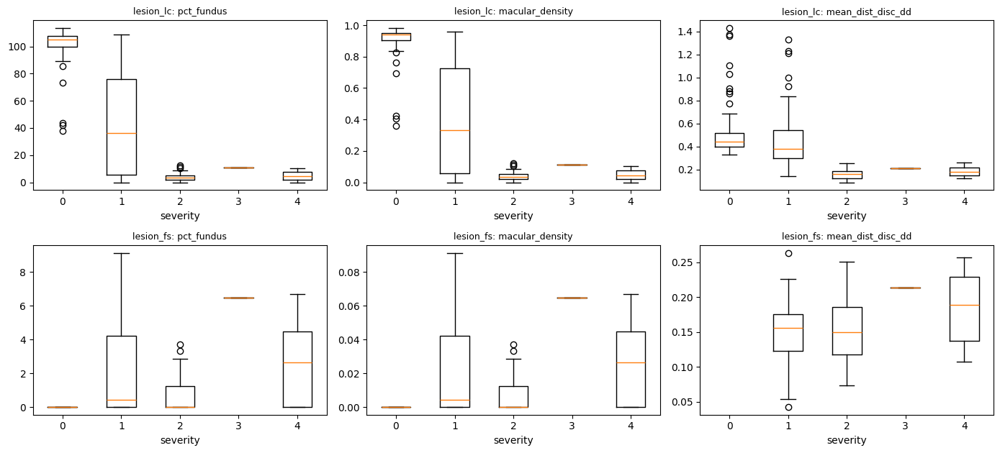

In [75]:
lesion_tasks = [t for t in ACTIVE_SEG if t != 'disc']
sev_rows = test_out.dropna(subset=['severity']) if USE_SEV else test_out.iloc[0:0]
fig, axes = plt.subplots(len(lesion_tasks), 3, figsize=(14, 3.2 * max(len(lesion_tasks), 1)), squeeze=False)
for i, t in enumerate(lesion_tasks):
    for j, col in enumerate(['pct_fundus', 'macular_density', 'mean_dist_disc_dd']):
        c = f'{t}_pred_{col}'
        if c in sev_rows and len(sev_rows):
            groups = [sev_rows[sev_rows.severity == k][c].dropna().values for k in range(len(SEVERITY_NAMES))]
            axes[i, j].boxplot(groups, labels=range(len(SEVERITY_NAMES)))
        axes[i, j].set_title(f'{t}: {col}', fontsize=9)
        axes[i, j].set_xlabel('severity')
    if len(sev_rows):
        rho = spearmanr(sev_rows.severity, sev_rows[f'{t}_pred_pct_fundus'], nan_policy='omit')
        print(f'{t}: Spearman(severity, predicted % fundus) = {rho.correlation:.3f} (p = {rho.pvalue:.3g}, n = {len(sev_rows)})')
plt.tight_layout()
plt.show()

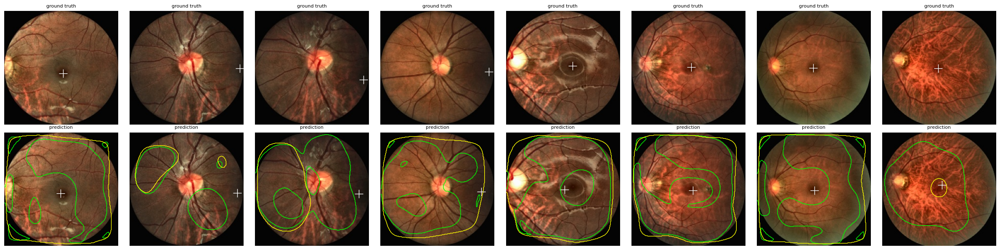

In [76]:
n_show = len(shown)
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6), squeeze=False)
colors = SEG_COLORS
for i, s in enumerate(shown):
    img = read_rgb(meta_prep.set_index('uid').loc[s['uid'], 'prep_image'])
    for row_i, key in enumerate(['gt', 'pred']):
        axes[row_i, i].imshow(img)
        for k, t in enumerate(ACTIVE_SEG):
            if key == 'pred' or s['has'][k] > 0:
                axes[row_i, i].contour(s[key][k], levels=[0.5], colors=colors[t], linewidths=1)
        pt = s['fov_gt'] if key == 'gt' else s['fov_pred']
        if pt is not None:
            axes[row_i, i].plot(pt[0], pt[1], 'w+', markersize=14)
        axes[row_i, i].axis('off')
    axes[0, i].set_title('ground truth', fontsize=8)
    axes[1, i].set_title('prediction', fontsize=8)
plt.tight_layout()
plt.show()

## 40. Explainability
Gradient-weighted class activation maps (Grad-CAM) on the PM output. For CNNs the target is the last convolutional stage; for Transformers it is the token features entering the last block, reshaped to a patch grid. For plain ViTs, attention rollout is added. Swin uses Grad-CAM only (its window attention does not roll out as simply).

In [77]:
CAM_LAYER = {
    'ResNet-50': lambda m: m.layer4[-1],
    'DenseNet-121': lambda m: m.features.norm5,
    'EfficientNet-B4': lambda m: m.bn2,
    'ViT-B/16': lambda m: m.blocks[-1].norm1,
    'Swin-Tiny': lambda m: m.layers[-1].blocks[-1].norm1,
    'RETFound': lambda m: m.blocks[-1].norm1,
}

def grad_cam(model, x):
    store = {}
    def hook(module, inputs, output):
        store['act'] = output
        output.register_hook(lambda grad: store.__setitem__('grad', grad))
    handle = CAM_LAYER[FINAL_NAME](model.backbone).register_forward_hook(hook)
    model.zero_grad()
    out = model(x)
    out['pm'].sum().backward()
    handle.remove()
    act, grad = to_map(store['act'], FINAL_KIND), to_map(store['grad'], FINAL_KIND)
    cam = F.relu((grad.mean((2, 3), keepdim=True) * act).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)[:, 0]
    cam = cam / (cam.amax((1, 2), keepdim=True) + 1e-8)
    return cam.detach().cpu().numpy(), torch.sigmoid(out['pm']).detach().cpu().numpy()

def attention_rollout(model, x):
    maps, hooks = [], []
    for blk in model.backbone.blocks:
        blk.attn.fused_attn = False
        hooks.append(blk.attn.attn_drop.register_forward_hook(lambda m, i, o: maps.append(o.detach())))
    with torch.no_grad():
        model(x)
    for h in hooks:
        h.remove()
    eye = torch.eye(maps[0].shape[-1], device=x.device)
    result = eye[None]
    for a in maps:
        a = a.mean(1) + eye
        result = (a / a.sum(-1, keepdim=True)) @ result
    flow = result[:, 1:, 1:].mean(1)               # contribution of each patch to the mean-pooled output
    side = int(flow.shape[1] ** 0.5)
    flow = F.interpolate(flow.reshape(-1, 1, side, side), size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)[:, 0]
    return (flow / (flow.amax((1, 2), keepdim=True) + 1e-8)).cpu().numpy()

def overlay(img, cam):
    heat = cv2.cvtColor(cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return (0.55 * img + 0.45 * heat).astype(np.uint8)

Examples: up to two each of true positives, true negatives, false positives, false negatives on the test set.

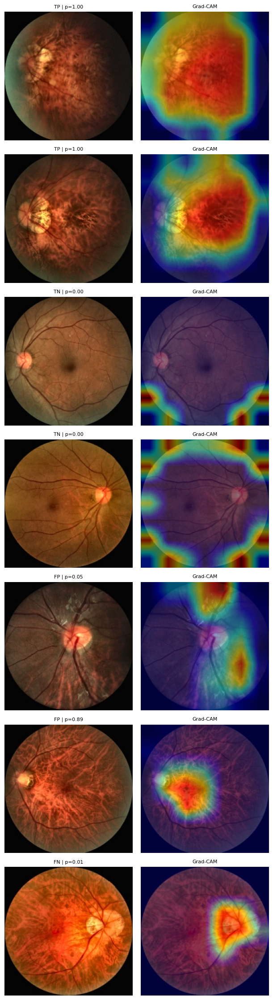

In [78]:
labelled = test_out.dropna(subset=['pm_label']).copy()
labelled['pred'] = (labelled.pm_prob >= mt_thr).astype(int)
picks = []
for name_, cond in [('TP', (labelled.pm_label == 1) & (labelled.pred == 1)), ('TN', (labelled.pm_label == 0) & (labelled.pred == 0)),
                    ('FP', (labelled.pm_label == 0) & (labelled.pred == 1)), ('FN', (labelled.pm_label == 1) & (labelled.pred == 0))]:
    picks += [(name_, u) for u in labelled[cond].sample(min(2, int(cond.sum())), random_state=SEED).uid]

test_ds = mt_test.dataset
uid_to_idx = {u: i for i, u in enumerate(test_ds.df.uid)}
ncols = 3 if FINAL_KIND == 'vit' else 2
fig, axes = plt.subplots(len(picks), ncols, figsize=(3.2 * ncols, 3.2 * len(picks)), squeeze=False)
mt_model.eval()
for r_i, (tag, uid) in enumerate(picks):
    item = test_ds[uid_to_idx[uid]]
    x = item['image'][None].to(DEVICE)
    cam, prob = grad_cam(mt_model, x)
    img = read_rgb(test_ds.df.iloc[uid_to_idx[uid]].prep_image)
    axes[r_i, 0].imshow(img)
    axes[r_i, 0].set_title(f'{tag} | p={prob[0]:.2f}', fontsize=8)
    axes[r_i, 1].imshow(overlay(img, cam[0]))
    axes[r_i, 1].set_title('Grad-CAM', fontsize=8)
    if FINAL_KIND == 'vit':
        axes[r_i, 2].imshow(overlay(img, attention_rollout(mt_model, x)[0]))
        axes[r_i, 2].set_title('attention rollout', fontsize=8)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.savefig(DIRS['explain'] / 'gradcam_examples.png', dpi=150)
plt.show()

Does the attention fall on clinically meaningful regions? For each mask type, the share of Grad-CAM energy inside the mask is divided by the mask's share of the image. A ratio above 1 means the model looks there more than chance.

In [79]:
enrich = {}
for t in ACTIVE_SEG:
    k = ACTIVE_SEG.index(t)
    ids = [i for i, u in enumerate(test_ds.df.uid) if isinstance(test_ds.df.iloc[i][f'prep_{t}'], str)][:100]
    ratios = []
    for i in ids:
        item = test_ds[i]
        cam, _ = grad_cam(mt_model, item['image'][None].to(DEVICE))
        mask = item['masks'][k].numpy() > 0.5
        if mask.sum() > 0 and cam.sum() > 0:
            ratios.append((cam[0][mask].sum() / cam[0].sum()) / (mask.sum() / mask.size))
    if ratios:
        enrich[t] = dict(n=len(ratios), mean_ratio=float(np.mean(ratios)), median_ratio=float(np.median(ratios)))
pd.DataFrame(enrich).T.round(3)

,n,mean_ratio,median_ratio
disc,5.0,1.000,1.000
lesion_lc,9.0,4.980,5.023
lesion_fs,11.0,2.142,1.785


*Interpretation, add after running:* where does the model look for correct vs wrong predictions, and are the enrichment ratios consistent with the visual examples?

## 41. Error analysis

PM errors per source dataset


,n,errors,false_neg,false_pos
dataset,,,,
MMAC2023,209,11,1,10
PALM,187,6,0,6


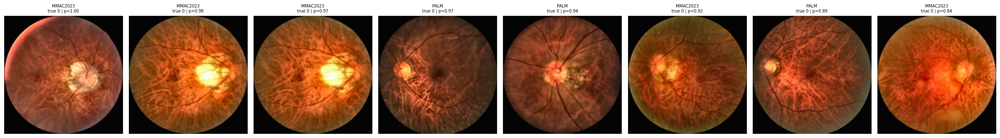

In [80]:
labelled['error'] = labelled.pred != labelled.pm_label
print('PM errors per source dataset')
display(labelled.groupby('dataset').agg(n=('uid', 'size'), errors=('error', 'sum'), false_neg=('pm_prob', lambda s: int(((s < mt_thr) & (labelled.loc[s.index, 'pm_label'] == 1)).sum())),
                                       false_pos=('pm_prob', lambda s: int(((s >= mt_thr) & (labelled.loc[s.index, 'pm_label'] == 0)).sum()))))

worst = labelled[labelled.error].assign(confidence=lambda d: (d.pm_prob - mt_thr).abs()).sort_values('confidence', ascending=False).head(8)
fig, axes = plt.subplots(1, max(len(worst), 1), figsize=(3 * max(len(worst), 1), 3.3), squeeze=False)
for ax, r in zip(axes[0], worst.itertuples()):
    ax.imshow(read_rgb(meta_prep.set_index('uid').loc[r.uid, 'prep_image']))
    ax.set_title(f'{r.dataset}\ntrue {int(r.pm_label)} | p={r.pm_prob:.2f}', fontsize=7)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

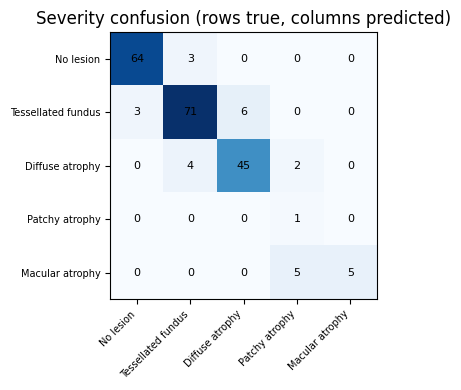

errors that are one level away: 23 of 23


In [81]:
if USE_SEV:
    s = test_out.dropna(subset=['severity'])
    cm = confusion_matrix(s.severity.astype(int), s.sev_pred, labels=range(len(SEVERITY_NAMES)))
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap='Blues')
    plt.xticks(range(len(SEVERITY_NAMES)), SEVERITY_NAMES, rotation=45, ha='right', fontsize=7)
    plt.yticks(range(len(SEVERITY_NAMES)), SEVERITY_NAMES, fontsize=7)
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, v, ha='center', va='center', fontsize=8)
    plt.title('Severity confusion (rows true, columns predicted)')
    plt.tight_layout()
    plt.show()
    print('errors that are one level away:', f'{((s.severity - s.sev_pred).abs() == 1).sum()} of {(s.severity != s.sev_pred).sum()}')

In [82]:
for t in ACTIVE_SEG:
    print(f'{t}: 5 lowest-Dice test images')
    print(test_out.dropna(subset=[f'dice_{t}']).nsmallest(5, f'dice_{t}')[['uid', 'dataset', f'dice_{t}']].to_string(index=False))
if USE_FOV and 'fovea_err_px' in test_out:
    print('fovea: 5 largest errors (px)')
    print(test_out.dropna(subset=['fovea_err_px']).nlargest(5, 'fovea_err_px')[['uid', 'dataset', 'fovea_err_px']].to_string(index=False))

disc: 5 lowest-Dice test images
                                                                            uid  dataset  dice_disc
 HRF-Seg+|datasets/rithikaa7/hrf-seg/HRF-Seg+/Folder_6_Original_Images/01_h.jpg HRF-Seg+        1.0
 HRF-Seg+|datasets/rithikaa7/hrf-seg/HRF-Seg+/Folder_6_Original_Images/11_g.jpg HRF-Seg+        1.0
 HRF-Seg+|datasets/rithikaa7/hrf-seg/HRF-Seg+/Folder_6_Original_Images/11_h.jpg HRF-Seg+        1.0
HRF-Seg+|datasets/rithikaa7/hrf-seg/HRF-Seg+/Folder_6_Original_Images/12_dr.JPG HRF-Seg+        1.0
 HRF-Seg+|datasets/rithikaa7/hrf-seg/HRF-Seg+/Folder_6_Original_Images/12_h.jpg HRF-Seg+        1.0
lesion_lc: 5 lowest-Dice test images
                                                                                                                                                            uid  dataset  dice_lesion_lc
MMAC2023|datasets/rithikaa7/mmac-2/2. Segmentation of Myopic Maculopathy Plus Lesions/1. Lacquer Cracks/1. Images/1. Training Set/mmac_task_2_trai

*Interpretation, add after running:* which source dataset or severity level drives the errors, and are mask/fovea failures concentrated in particular images?

## 42. Final comparison tables and plots

In [83]:
final_table = baseline_table[['val_auroc', 'test_auroc', 'test_auprc', 'test_f1', 'test_sensitivity', 'test_specificity']].copy()
final_table['stage'] = 'baseline'
imp_rows = []
for name, info_ in improved.items():
    row = summary_row(read_json(info_['dir'] / 'results.json'))
    row['model'] = f'{name} (improved: {info_["source"]})'
    row['stage'] = 'improved'
    imp_rows.append(row)
cols = list(final_table.columns)
final_table = pd.concat([final_table, pd.DataFrame(imp_rows).set_index('model')[cols]])
final_table.loc['Multi-task PM head (final model)'] = [np.nan, mt_metrics['pm']['auroc'], mt_metrics['pm']['auprc'], mt_metrics['pm']['f1'],
                                                       mt_metrics['pm']['sensitivity'], mt_metrics['pm']['specificity'], 'multi-task']
final_table.to_csv(DIRS['results'] / 'final_comparison_table.csv')
final_table

,val_auroc,test_auroc,test_auprc,test_f1,test_sensitivity,test_specificity,stage
model,,,,,,,
ResNet-50,0.981782,0.992098,0.988469,0.900000,0.993506,0.863636,baseline
DenseNet-121,0.986714,0.995895,0.994180,0.935385,0.987013,0.921488,baseline
EfficientNet-B4,0.985511,0.988019,0.982702,0.900901,0.974026,0.880165,baseline
ViT-B/16,0.987583,0.995667,0.993541,0.938272,0.987013,0.925620,baseline
Swin-Tiny,0.990951,0.996834,0.995411,0.941176,0.987013,0.929752,baseline
RETFound,0.989427,0.995787,0.993563,0.955414,0.974026,0.958678,baseline
ResNet-50 (improved: head_lr_x10),0.988158,0.993265,0.990927,0.939683,0.961039,0.946281,improved
DenseNet-121 (improved: pos_weight),0.990804,0.995277,0.992878,0.941176,0.987013,0.929752,improved
EfficientNet-B4 (improved: original),0.985511,0.988019,0.982702,0.900901,0.974026,0.880165,improved


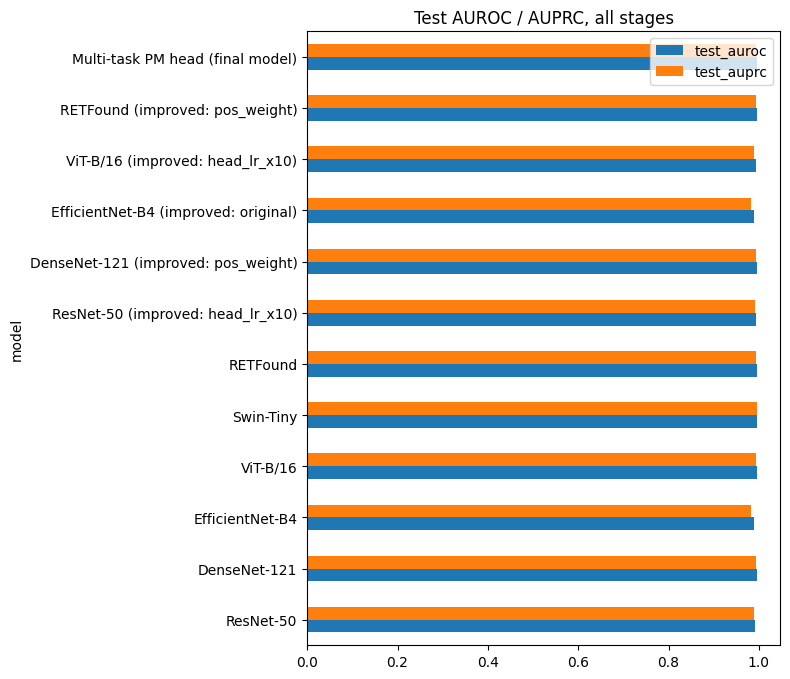

In [84]:
plot = final_table[['test_auroc', 'test_auprc']].astype(float)
plot.plot.barh(figsize=(8, 0.45 * len(plot) + 1.5), title='Test AUROC / AUPRC, all stages')
plt.tight_layout()
plt.savefig(DIRS['results'] / 'final_comparison.png', dpi=150)
plt.show()

## 43. Save predictions, metrics, configurations and checkpoints

In [85]:
summary = dict(seed=SEED, img_size=IMG_SIZE, torch=torch.__version__, timm=timm.__version__, albumentations=A.__version__,
               benchmark=BENCHMARK, final_model=FINAL_NAME, final_source=FINAL['source'], base_cfg=BASE_CFG,
               improved={n: dict(source=i['source'], accepted=i['accepted'], cfg=i['cfg']) for n, i in improved.items()},
               multitask_cfg=MT_CFG, active_seg=ACTIVE_SEG, use_severity=USE_SEV, use_fovea=USE_FOV,
               macular_radius_dd=MAC_R, peripapillary_radius_dd=PERI_R, pm_threshold_multitask=mt_thr)
json.dump(summary, open(DIRS['results'] / 'run_summary.json', 'w'), indent=1, default=str)

for f in sorted(WORK.rglob('*')):
    if f.is_file() and f.suffix in ['.pth', '.json', '.csv', '.png']:
        print(f'{f.relative_to(WORK)}  {f.stat().st_size / 1e6:.1f} MB')

baseline/DenseNet-121/best.pth  28.4 MB
baseline/DenseNet-121/history.csv  0.0 MB
baseline/DenseNet-121/predictions.csv  0.3 MB
baseline/DenseNet-121/results.json  0.0 MB
baseline/EfficientNet-B4/best.pth  70.9 MB
baseline/EfficientNet-B4/history.csv  0.0 MB
baseline/EfficientNet-B4/predictions.csv  0.3 MB
baseline/EfficientNet-B4/results.json  0.0 MB
baseline/RETFound/best.pth  1213.3 MB
baseline/RETFound/history.csv  0.0 MB
baseline/RETFound/predictions.csv  0.3 MB
baseline/RETFound/results.json  0.0 MB
baseline/ResNet-50/best.pth  94.3 MB
baseline/ResNet-50/history.csv  0.0 MB
baseline/ResNet-50/predictions.csv  0.3 MB
baseline/ResNet-50/results.json  0.0 MB
baseline/Swin-Tiny/best.pth  110.1 MB
baseline/Swin-Tiny/history.csv  0.0 MB
baseline/Swin-Tiny/predictions.csv  0.3 MB
baseline/Swin-Tiny/results.json  0.0 MB
baseline/ViT-B_16/best.pth  343.2 MB
baseline/ViT-B_16/history.csv  0.0 MB
baseline/ViT-B_16/predictions.csv  0.3 MB
baseline/ViT-B_16/results.json  0.0 MB
baseline/bench